<a href="https://colab.research.google.com/github/queensss/Algorithms/blob/main/1st_Final_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sb
import os
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from scipy.stats import shapiro
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer



In [ ]:

df = pd.read_excel("/content/bdhs2022_final_analysis_dataset_new - Copy.xlsx")

In [ ]:
df.head()

,age_months,sample_weight,cluster_id,hh_id,child_line,mother_edu,birth_order,mother_occ,birth_interval_months,children_ever_born,...,toilet_improved,delivery_place_3cat,has_tv_clean,has_electricity_clean,reads_newspaper_clean,small_at_birth,wants_more_children,wealth_index_clean,stunted,haz
0,32.0,156207,1.0,111.0,1,3,2.0,1,63.0,2.0,...,1,1,1,1,1,0,0,4,0,0.08
1,18.0,141953,2.0,3.0,1,2,2.0,0,56.0,2.0,...,0,2,1,1,0,0,0,4,0,-1.61
2,14.0,141953,2.0,23.0,1,3,1.0,0,NaN,1.0,...,1,2,1,1,0,1,1,5,0,-1.29
3,NaN,141953,2.0,34.0,1,3,3.0,0,46.0,3.0,...,1,2,1,1,0,0,1,4,1,-2.27
4,5.0,141953,2.0,146.0,1,2,2.0,0,24.0,2.0,...,1,2,1,1,1,1,1,5,0,-0.31


In [ ]:
df.tail()

,age_months,sample_weight,cluster_id,hh_id,child_line,mother_edu,birth_order,mother_occ,birth_interval_months,children_ever_born,...,toilet_improved,delivery_place_3cat,has_tv_clean,has_electricity_clean,reads_newspaper_clean,small_at_birth,wants_more_children,wealth_index_clean,stunted,haz
2486,6.0,699635,675.0,31.0,1,1,4.0,0,77.0,4.0,...,1,1,0,1,0,0,0,2,0,-1.92
2487,23.0,699635,675.0,41.0,2,0,2.0,0,34.0,3.0,...,0,0,0,1,0,0,1,2,1,-3.10
2488,2.0,699635,675.0,70.0,1,1,3.0,0,25.0,3.0,...,1,2,0,1,0,0,0,1,0,-0.47
2489,28.0,699635,675.0,70.0,2,1,2.0,0,41.0,3.0,...,1,0,0,1,0,0,0,1,0,-1.79
2490,12.0,699635,675.0,108.0,1,2,2.0,0,34.0,2.0,...,0,0,0,1,0,0,0,2,0,-1.00


In [ ]:
df.shape

(2491, 27)

In [ ]:
print(df.columns.tolist())

['age_months', 'sample_weight', 'cluster_id', 'hh_id', 'child_line', 'mother_edu', 'birth_order', 'mother_occ', 'birth_interval_months', 'children_ever_born', 'father_edu', 'division', 'mother_age', 'wt', 'mother_bmi', 'father_occ_clean', 'skilled_birth', 'toilet_improved', 'delivery_place_3cat', 'has_tv_clean', 'has_electricity_clean', 'reads_newspaper_clean', 'small_at_birth', 'wants_more_children', 'wealth_index_clean', 'stunted', 'haz']


In [ ]:
df.columns.tolist()

['age_months',
 'sample_weight',
 'cluster_id',
 'hh_id',
 'child_line',
 'mother_edu',
 'birth_order',
 'mother_occ',
 'birth_interval_months',
 'children_ever_born',
 'father_edu',
 'division',
 'mother_age',
 'wt',
 'mother_bmi',
 'father_occ_clean',
 'skilled_birth',
 'toilet_improved',
 'delivery_place_3cat',
 'has_tv_clean',
 'has_electricity_clean',
 'reads_newspaper_clean',
 'small_at_birth',
 'wants_more_children',
 'wealth_index_clean',
 'stunted',
 'haz']

 missing value check  
# heatmap

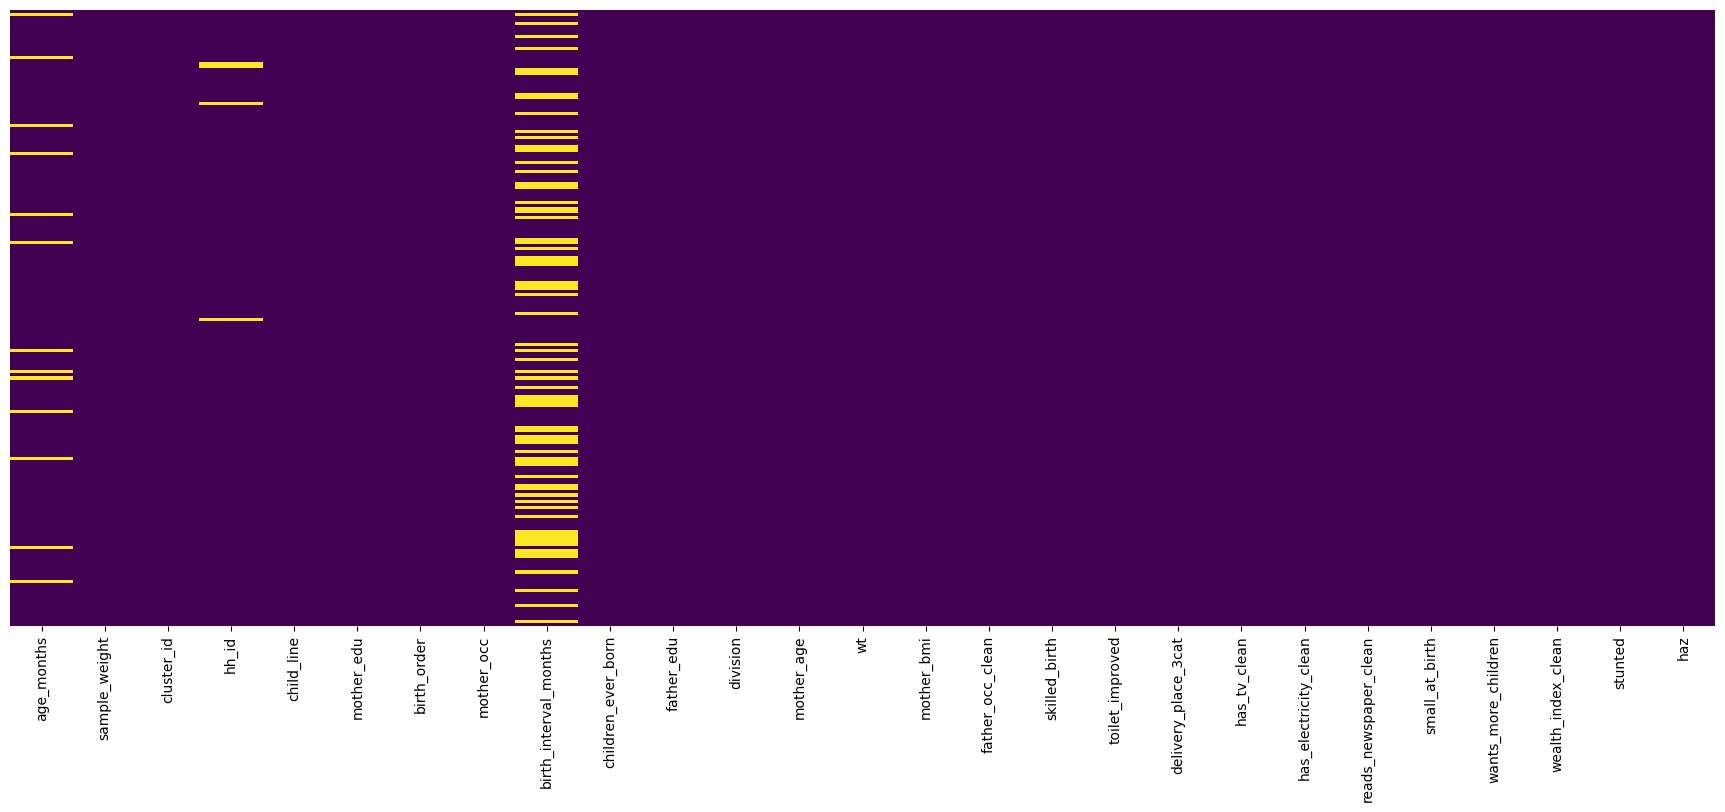

In [ ]:
plt.figure(figsize=(22, 8))
sns.heatmap(
  df.sample(200).isnull(),  # sample rows
    yticklabels=False,
    cbar=False,
    cmap='viridis'
)
plt.show()


# Bar chart

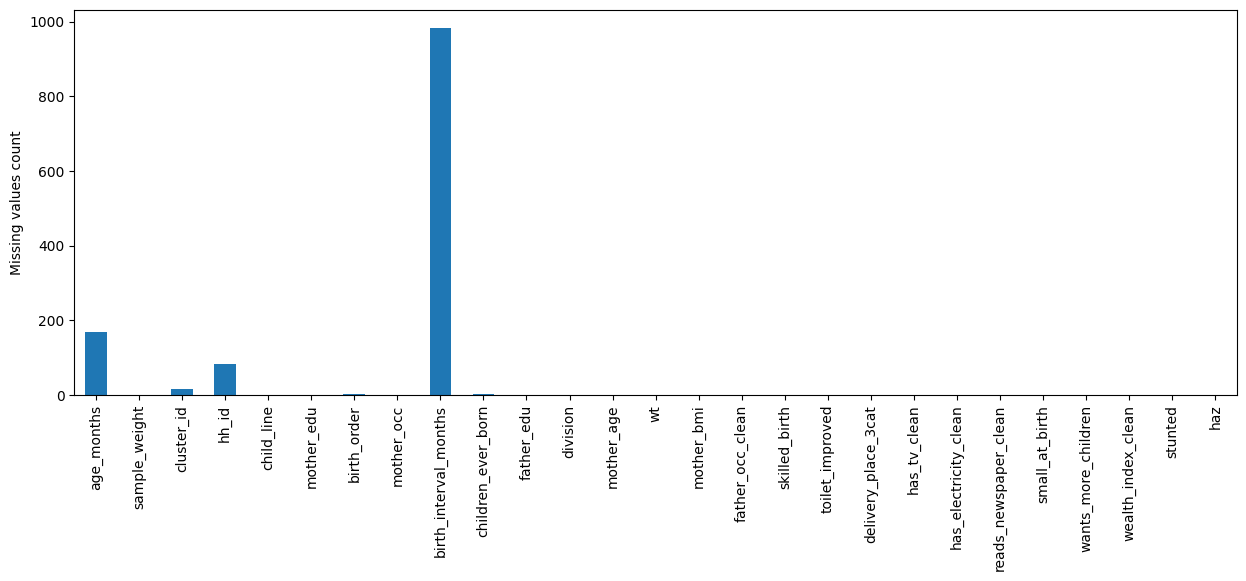

In [ ]:
df.isnull().sum().plot(kind='bar', figsize=(15,5))
plt.ylabel("Missing values count")
plt.show() # bar chart


In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_percent.index,
    'Missing_Percent': missing_percent.values
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_df)

                 Variable  Missing_Percent
8   birth_interval_months        39.462063
0              age_months         6.744279
3                   hh_id         3.291851
2              cluster_id         0.602168
9      children_ever_born         0.080289
6             birth_order         0.080289
14             mother_bmi         0.040145
5              mother_edu         0.000000
4              child_line         0.000000
7              mother_occ         0.000000
1           sample_weight         0.000000
10             father_edu         0.000000
11               division         0.000000
12             mother_age         0.000000
13                     wt         0.000000
15       father_occ_clean         0.000000
16          skilled_birth         0.000000
17        toilet_improved         0.000000
18    delivery_place_3cat         0.000000
19           has_tv_clean         0.000000
20  has_electricity_clean         0.000000
21  reads_newspaper_clean         0.000000
22         

In [ ]:
df = df.drop(columns=['hh_id', 'cluster_id'])

In [ ]:
df.shape

(2491, 25)

In [ ]:
missing_percent = df.isnull().mean() * 100

In [ ]:
threshold = 30


In [ ]:
df = df.loc[:, missing_percent <= threshold]


In [ ]:
cols_to_drop = missing_percent[missing_percent > 30].index
print(cols_to_drop)


Index(['birth_interval_months'], dtype='object')


In [ ]:
df.shape

(2491, 24)

In [ ]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols

Index(['age_months', 'sample_weight', 'child_line', 'mother_edu',
       'birth_order', 'mother_occ', 'children_ever_born', 'father_edu',
       'division', 'mother_age', 'wt', 'mother_bmi', 'father_occ_clean',
       'skilled_birth', 'toilet_improved', 'delivery_place_3cat',
       'has_tv_clean', 'has_electricity_clean', 'reads_newspaper_clean',
       'small_at_birth', 'wants_more_children', 'wealth_index_clean',
       'stunted', 'haz'],
      dtype='object')

In [ ]:
id_vars = ['cluster_id', 'hh_id', 'child_line']


In [ ]:
numeric_vars = [
   'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]


In [ ]:
all_df_cols = df.columns.tolist()

# Filter id_vars to only include columns that are still in df
current_id_vars = [col for col in id_vars if col in all_df_cols]

# Filter numeric_vars to only include columns that are still in df
current_numeric_vars = [col for col in numeric_vars if col in all_df_cols]

categorical_vars = list(
    set(all_df_cols) - set(current_id_vars) - set(current_numeric_vars)
)



In [ ]:
print("ID variables:\n", id_vars)
print("\nNumeric variables:\n", numeric_vars)
print("\nCategorical variables:\n", categorical_vars)


ID variables:
 ['cluster_id', 'hh_id', 'child_line']

Numeric variables:
 ['age_months', 'children_ever_born', 'mother_age', 'birth_order', 'mother_bmi']

Categorical variables:
 ['haz', 'father_occ_clean', 'wealth_index_clean', 'mother_occ', 'wt', 'sample_weight', 'small_at_birth', 'mother_edu', 'toilet_improved', 'wants_more_children', 'skilled_birth', 'has_tv_clean', 'delivery_place_3cat', 'division', 'stunted', 'father_edu', 'reads_newspaper_clean', 'has_electricity_clean']


# Normality check

In [ ]:


# Numeric (continuous) variables from our dataset
numeric_vars = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

normality_results = []

for col in numeric_vars:
    data = df[col].dropna()

    # Skip very small samples
    if len(data) < 10:
        continue

    skewness = data.skew()

    # Shapiro test (sample if dataset is large)
    stat, p_value = shapiro(data.sample(500) if len(data) > 500 else data)

    normality_results.append({
        "Variable": col,
        "Skewness": round(skewness, 3),
        "Shapiro_p_value": round(p_value, 4),
        "Distribution": "Normal" if p_value > 0.05 else "Non-normal"
    })

# Create normality table
normality_table = pd.DataFrame(normality_results)

normality_table


,Variable,Skewness,Shapiro_p_value,Distribution
0,age_months,-0.062,0.0,Non-normal
1,children_ever_born,1.200,0.0,Non-normal
2,mother_age,0.543,0.0,Non-normal
3,birth_order,1.207,0.0,Non-normal
4,mother_bmi,0.687,0.0,Non-normal


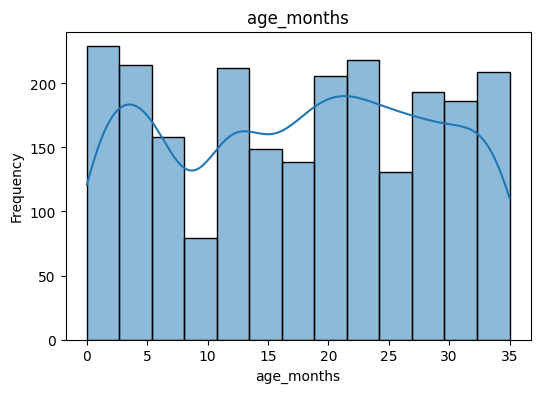

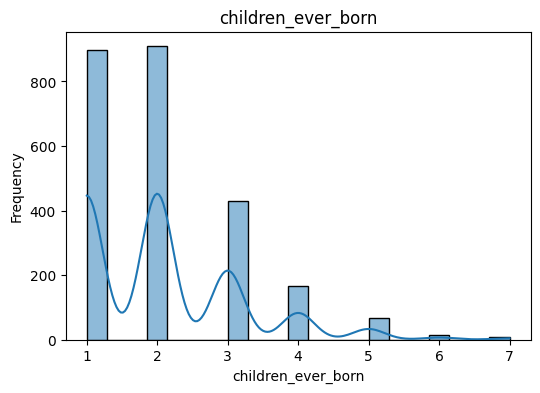

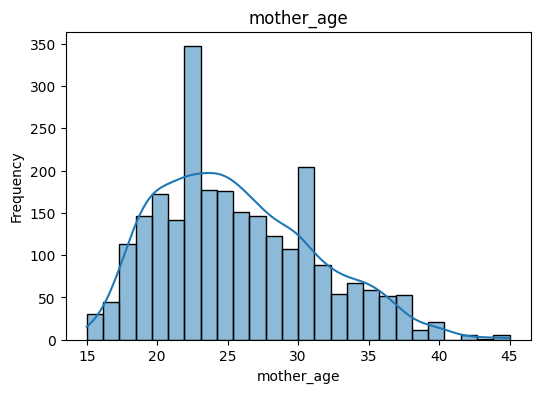

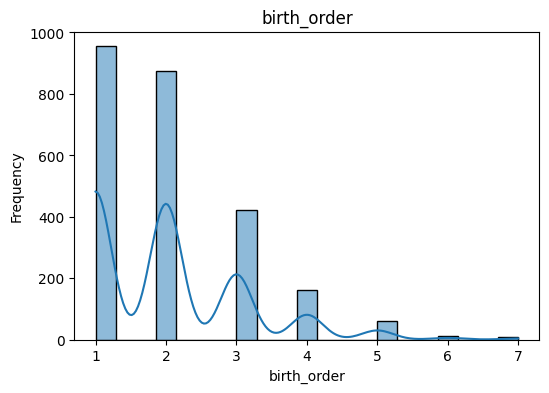

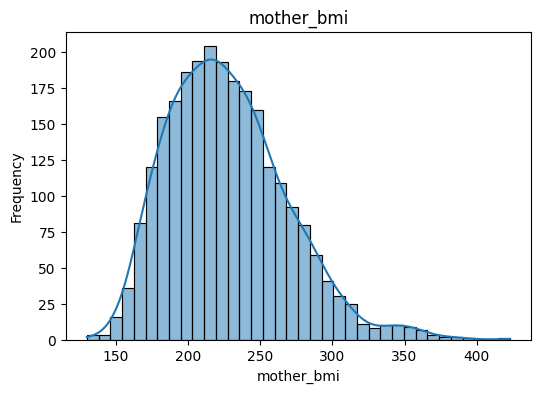

In [ ]:


# List of numeric variables (non-normal)
numeric_cols = [
      'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

# Plot each variable individually
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)   # pass only one column at a time
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# MICE PMM

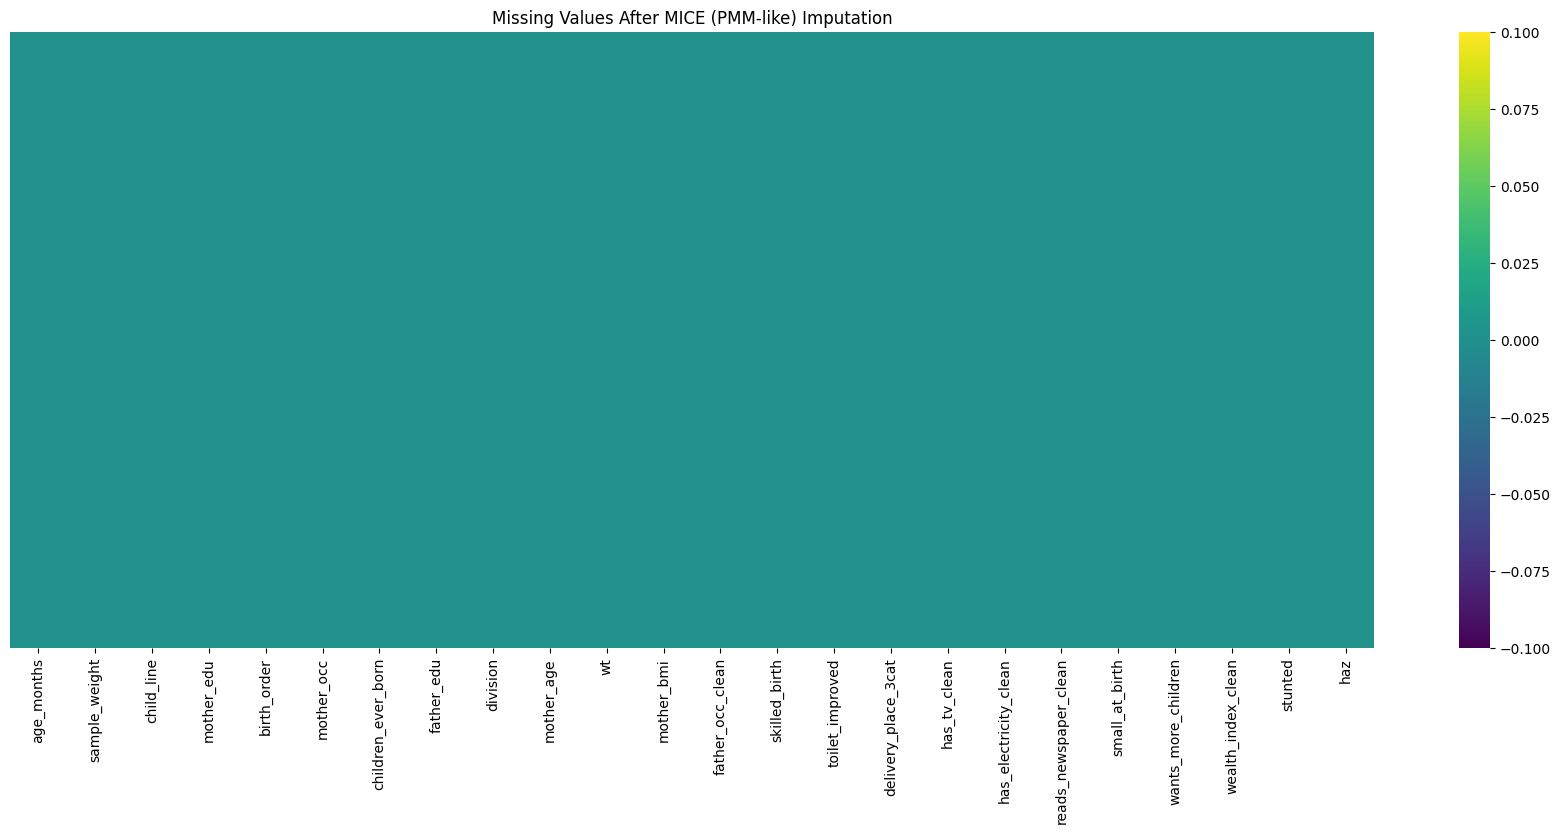

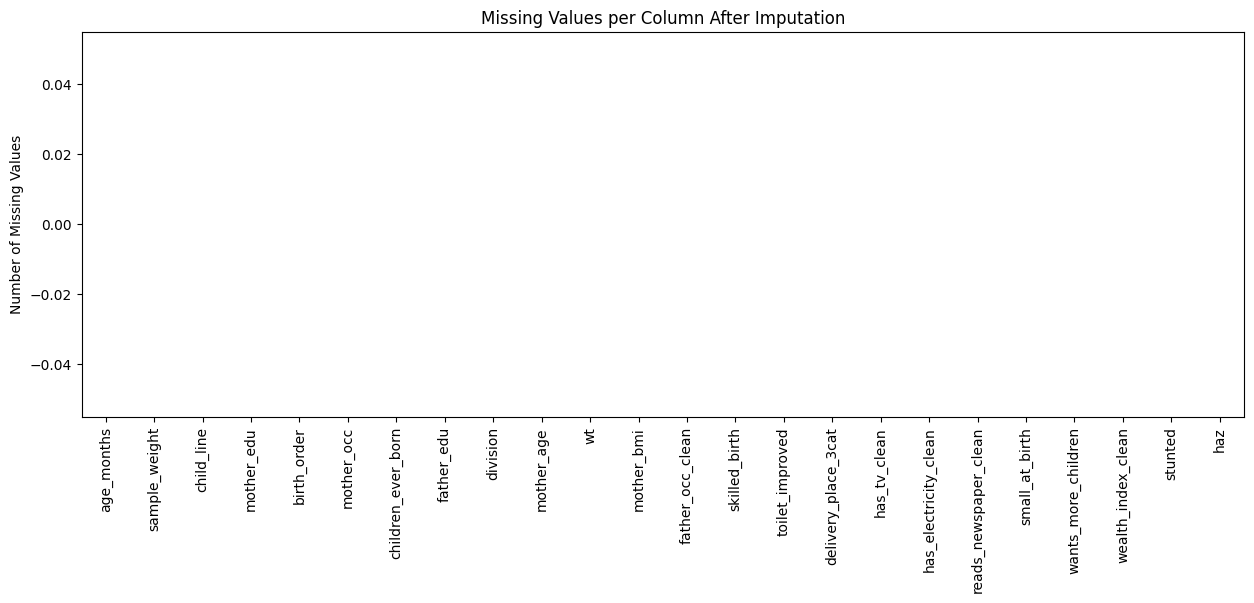

Total missing values after imputation: 0


In [ ]:

# =============================
# Imports (Colab compatible)
# =============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# =============================
# Load data (example)
# =============================
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

# =============================
# Define NON-NORMAL variables
# =============================
non_normal_vars = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',]

# =============================
# MICE / PMM-like Imputation
# =============================
mice_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42,
    sample_posterior=True
)

df[non_normal_vars] = mice_imputer.fit_transform(df[non_normal_vars])

# =============================
# Check missing values
# =============================
plt.figure(figsize=(22, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title("Missing Values After MICE (PMM-like) Imputation")
plt.show()

df.isnull().sum().sort_values(ascending=False).plot(
    kind='bar', figsize=(15, 5)
)
plt.ylabel("Number of Missing Values")
plt.title("Missing Values per Column After Imputation")
plt.show()

print("Total missing values after imputation:", df.isnull().sum().sum())

In [ ]:
import pandas as pd

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_percent.index,
    'Missing_Percent': missing_percent.values
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_df)



                 Variable  Missing_Percent
0              age_months              0.0
1           sample_weight              0.0
2              child_line              0.0
3              mother_edu              0.0
4             birth_order              0.0
5              mother_occ              0.0
6      children_ever_born              0.0
7              father_edu              0.0
8                division              0.0
9              mother_age              0.0
10                     wt              0.0
11             mother_bmi              0.0
12       father_occ_clean              0.0
13          skilled_birth              0.0
14        toilet_improved              0.0
15    delivery_place_3cat              0.0
16           has_tv_clean              0.0
17  has_electricity_clean              0.0
18  reads_newspaper_clean              0.0
19         small_at_birth              0.0
20    wants_more_children              0.0
21     wealth_index_clean              0.0
22         

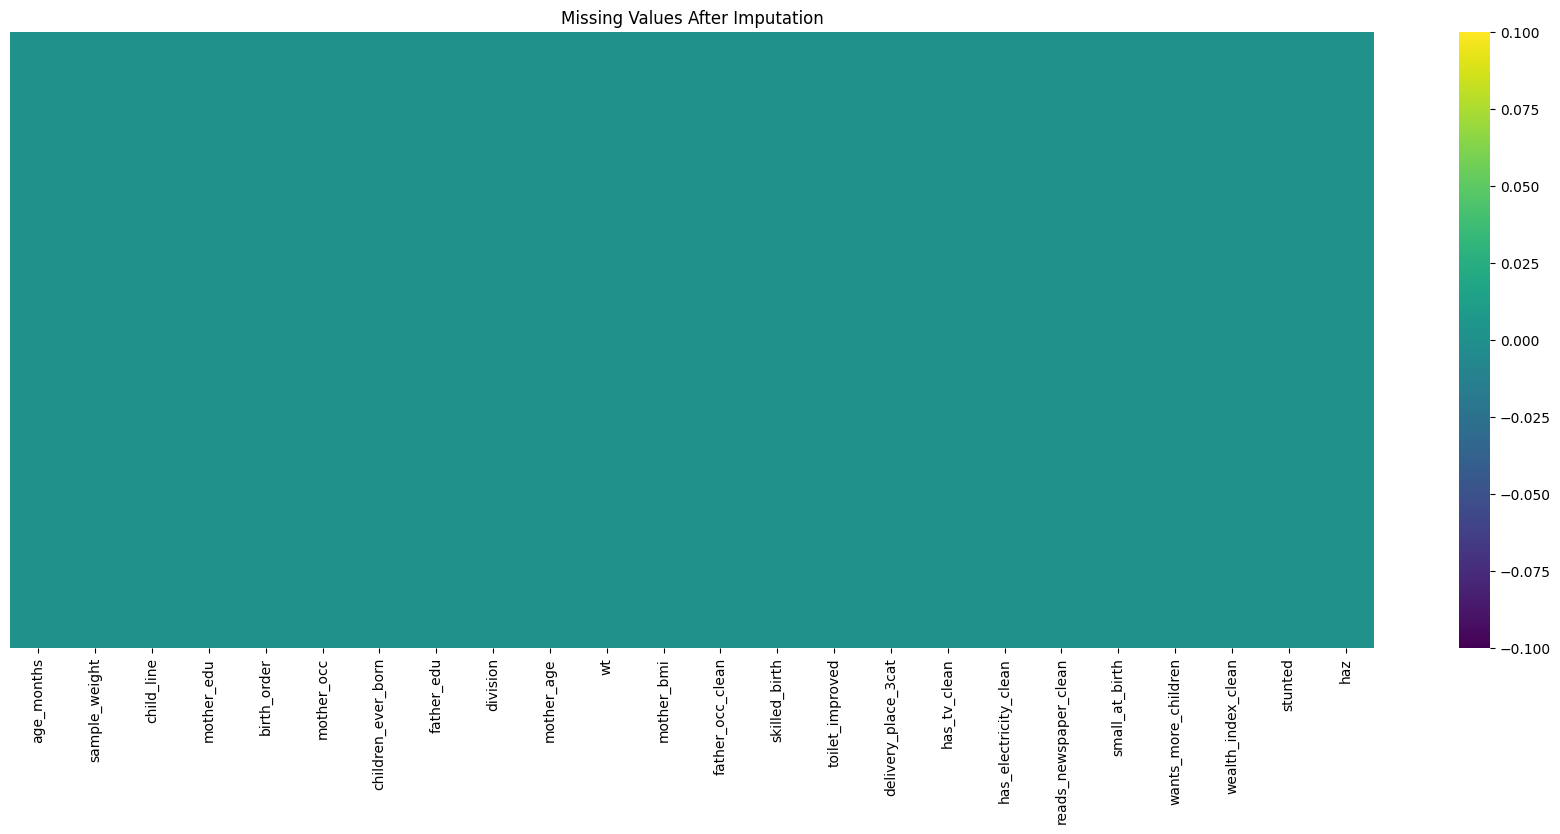

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(22,8))  # make it wide enough for all columns
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis')

plt.title("Missing Values After Imputation")
plt.show()


aftre missing value handled we have 24 variable

In [ ]:
df.shape

(2491, 24)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age_months,2491.0,1.758312e+01,10.654874,-5.135347,7.000000,18.000000,2.600000e+01,4.583307e+01
sample_weight,2491.0,1.017775e+06,512971.185567,91325.000000,670684.000000,956806.000000,1.333414e+06,3.891736e+06
child_line,2491.0,1.045363e+00,0.211965,1.000000,1.000000,1.000000,1.000000e+00,3.000000e+00
mother_edu,2491.0,1.867122e+00,0.785158,0.000000,1.000000,2.000000,2.000000e+00,3.000000e+00
birth_order,2491.0,2.017559e+00,1.078969,1.000000,1.000000,2.000000,3.000000e+00,7.000000e+00
mother_occ,2491.0,2.079486e-01,0.405921,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00
children_ever_born,2491.0,2.063017e+00,1.094907,1.000000,1.000000,2.000000,3.000000e+00,7.000000e+00
father_edu,2491.0,1.615415e+00,0.970564,0.000000,1.000000,2.000000,2.000000e+00,3.000000e+00
division,2491.0,3.586511e+00,1.925741,1.000000,2.000000,3.000000,5.000000e+00,7.000000e+00
mother_age,2491.0,2.567041e+01,5.577652,15.000000,21.000000,25.000000,2.900000e+01,4.500000e+01


In [ ]:
# Ensure lists match existing columns
numeric_vars = [col for col in numeric_vars if col in df.columns]
categorical_vars = [col for col in categorical_vars if col in df.columns]

# Convert numeric-coded categorical variables to 'category' type
for col in categorical_vars:
    df[col] = df[col].astype('category')

# Now describe
print(df[numeric_vars].describe())
print(df[categorical_vars].describe())


        age_months  children_ever_born   mother_age  birth_order   mother_bmi
count  2491.000000         2491.000000  2491.000000  2491.000000  2491.000000
mean     17.583119            2.063017    25.670413     2.017559   227.291901
std      10.654874            1.094907     5.577652     1.078969    41.025877
min      -5.135347            1.000000    15.000000     1.000000   130.000000
25%       7.000000            1.000000    21.000000     1.000000   196.500000
50%      18.000000            2.000000    25.000000     2.000000   223.000000
75%      26.000000            3.000000    29.000000     3.000000   251.850000
max      45.833074            7.000000    45.000000     7.000000   422.700000
            haz  father_occ_clean  wealth_index_clean  mother_occ  \
count   2491.00              2491                2491        2491   
unique   563.00                 6                   5           2   
top       -1.05                 7                   1           0   
freq      16.00       

### **Univariate Analysis (1st numerical 2nd categorical)**
# histplot and countplot to understand  the distribution




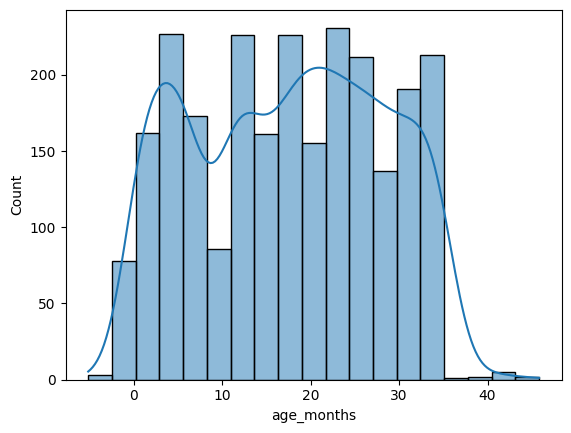

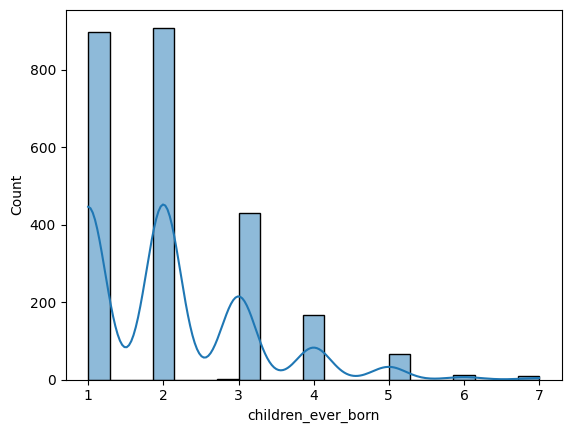

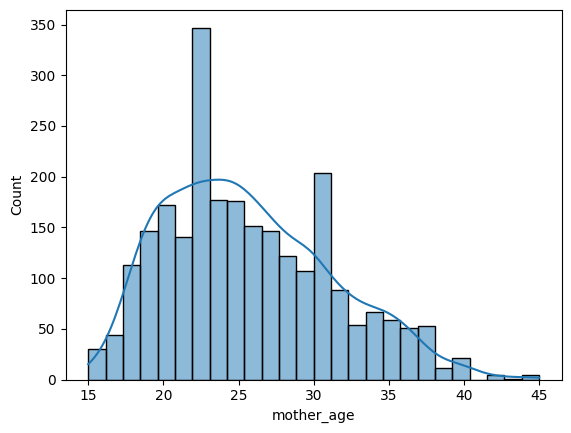

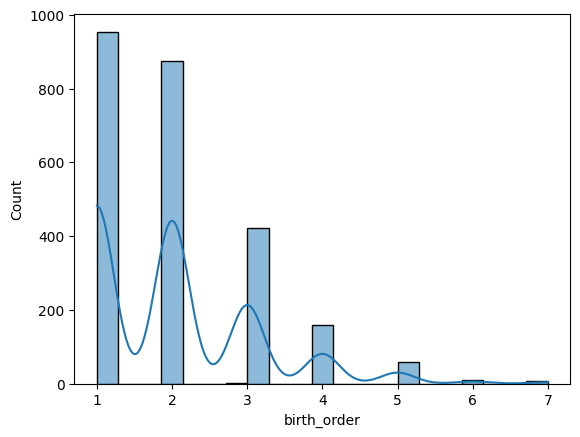

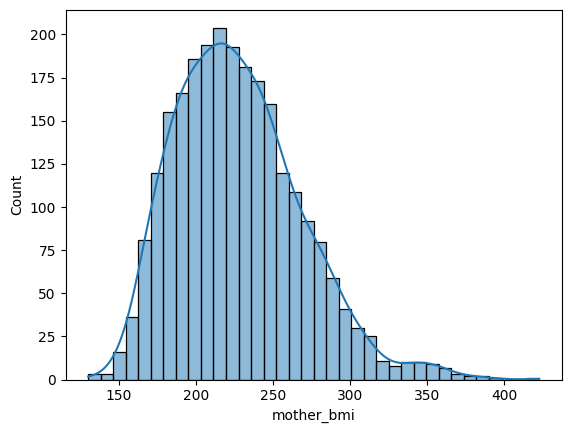

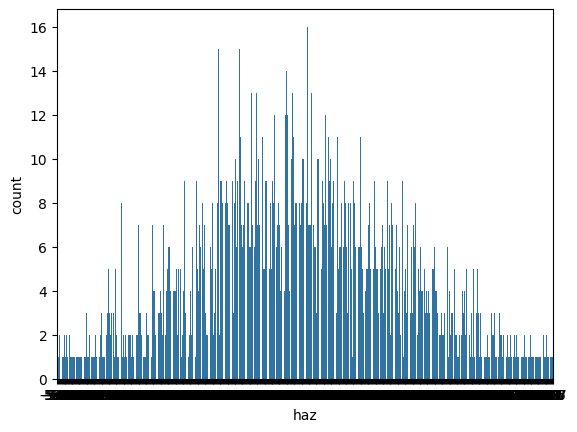

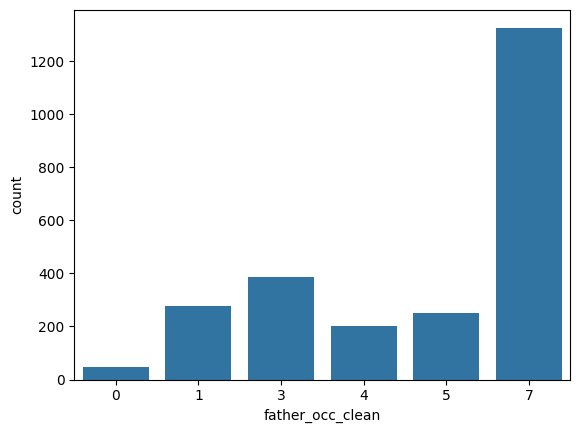

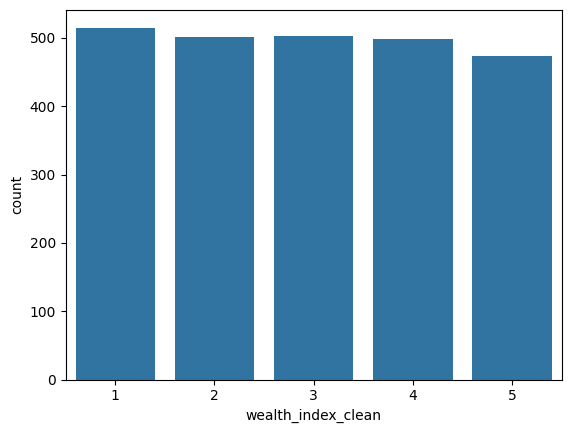

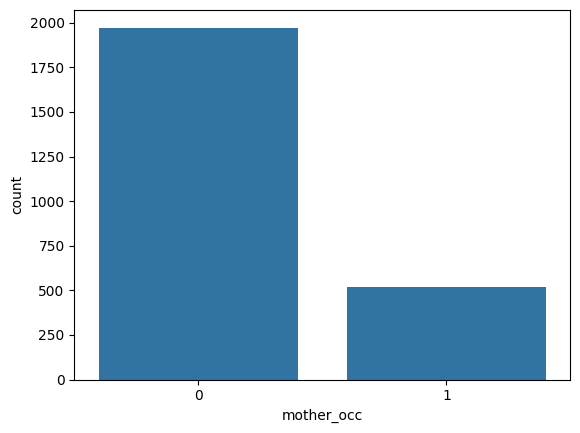

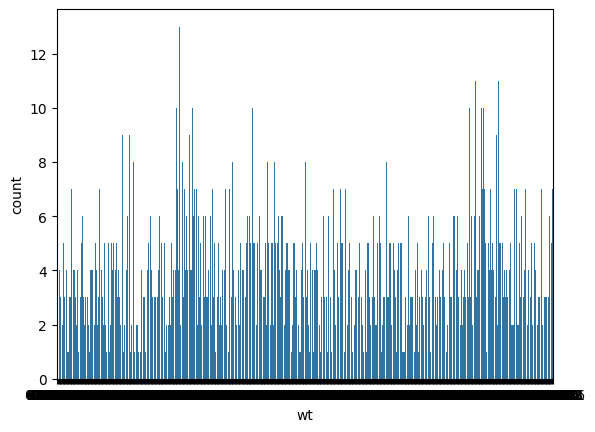

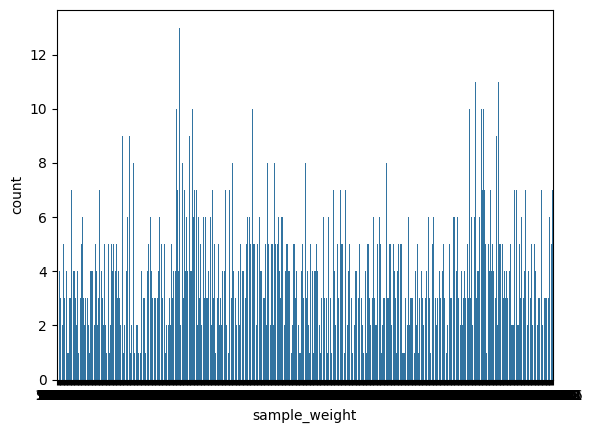

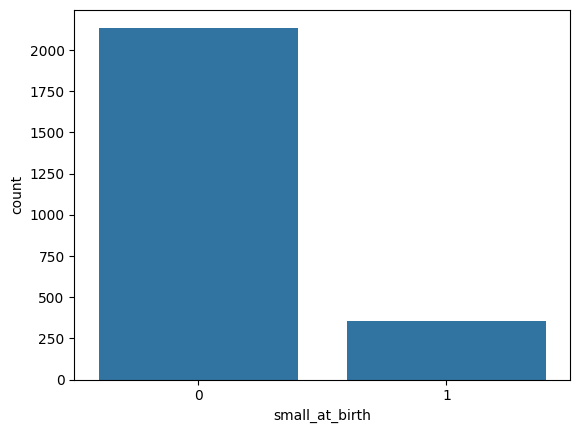

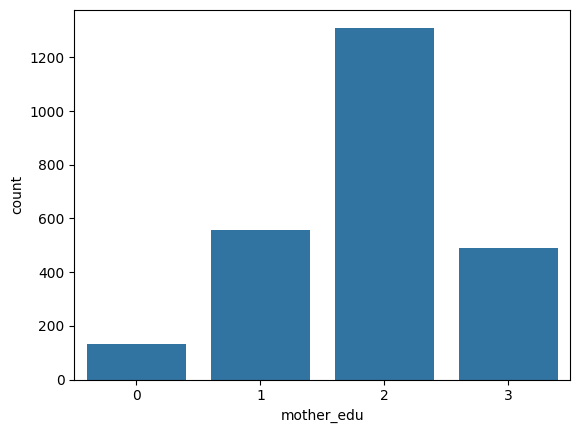

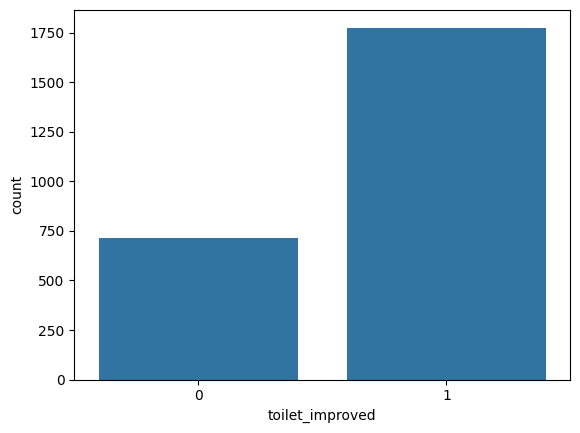

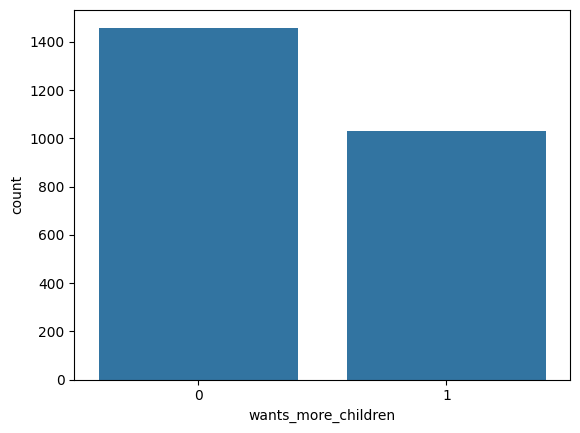

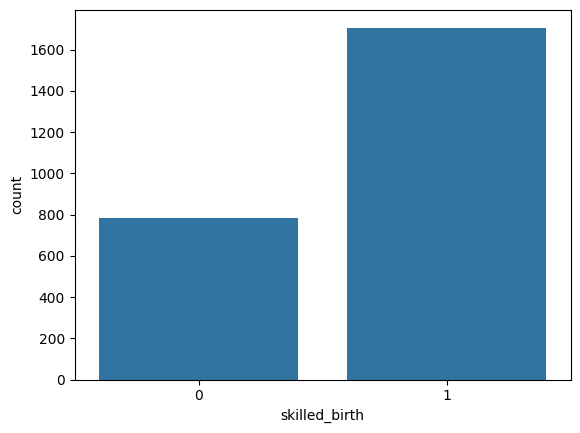

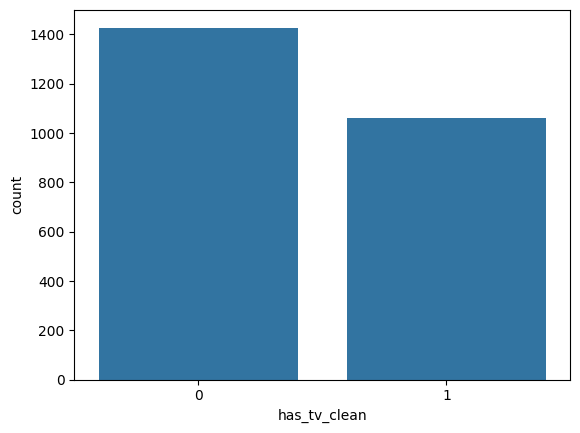

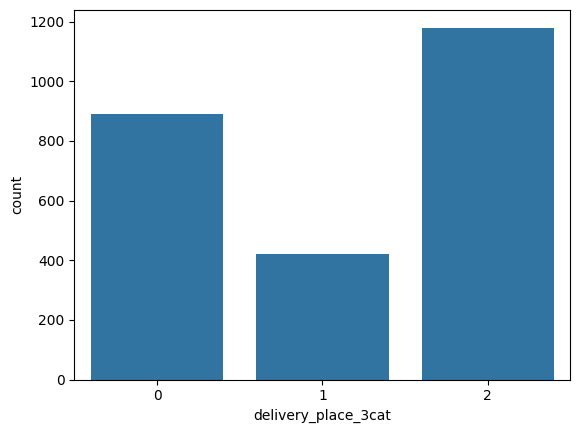

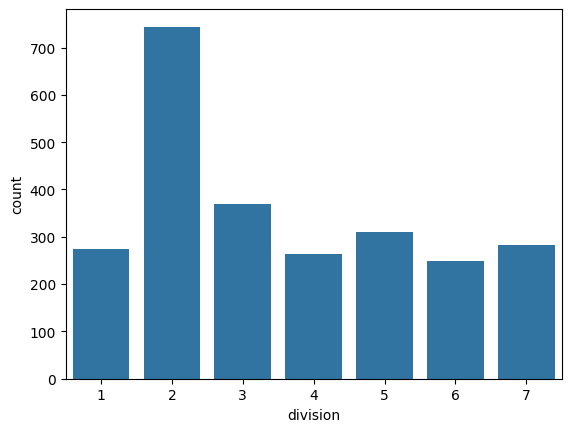

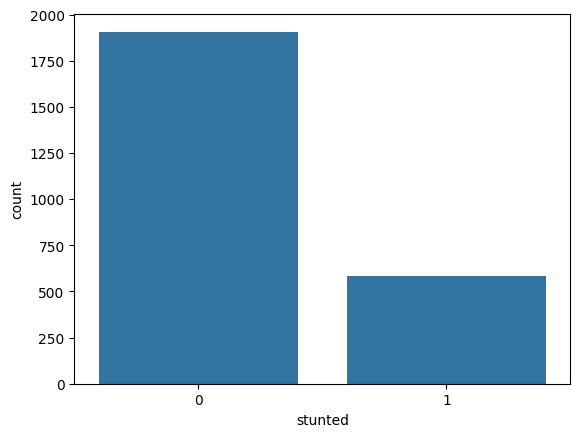

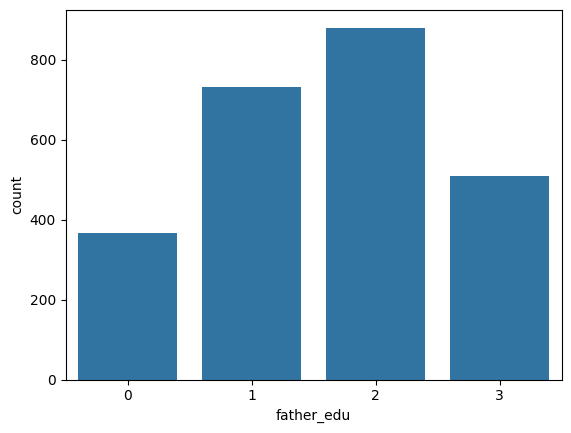

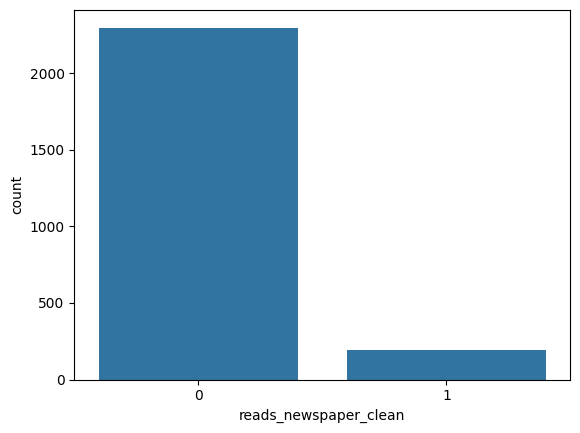

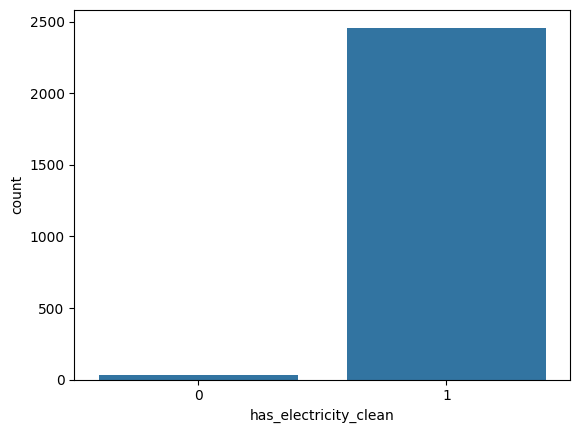

In [ ]:
# Numeric
for col in numeric_vars:
    sns.histplot(df[col], kde=True)
    plt.show()

# Categorical
for col in categorical_vars:
    sns.countplot(x=df[col])
    plt.show()

### Correlation heatmap for Numerical variable.

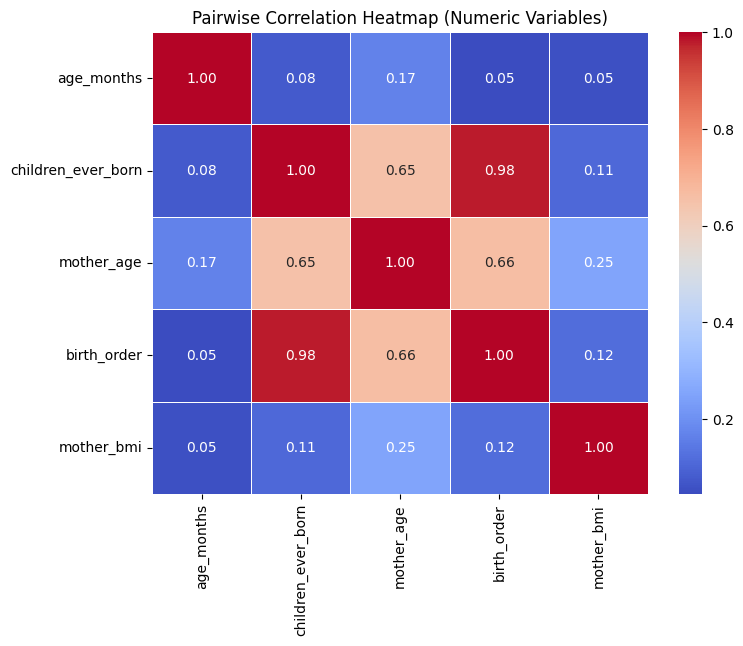

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric variables only
numeric_vars = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi'
]

# Compute correlation matrix
corr_matrix = df[numeric_vars].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Pairwise Correlation Heatmap (Numeric Variables)")
plt.show()


#boxplot to identify the outlier

In [ ]:
def iqr_outliers(df, columns):
    outlier_info = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lb = Q1 - 1.5 * IQR
        ub = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lb) | (df[col] > ub)]

        outlier_info[col] = {
            "lower_bound": lb,
            "upper_bound": ub,
            "num_outliers": outliers.shape[0]
        }

    return outlier_info


In [ ]:
columns_to_check = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

outlier_results = iqr_outliers(df, columns_to_check)


In [ ]:
for col, stats in outlier_results.items():
    print(f"\nColumn: {col}")
    print("Lower bound:", stats["lower_bound"])
    print("Upper bound:", stats["upper_bound"])
    print("Number of outliers:", stats["num_outliers"])



Column: age_months
Lower bound: -21.5
Upper bound: 54.5
Number of outliers: 0

Column: children_ever_born
Lower bound: -2.0
Upper bound: 6.0
Number of outliers: 8

Column: mother_age
Lower bound: 9.0
Upper bound: 41.0
Number of outliers: 11

Column: birth_order
Lower bound: -2.0
Upper bound: 6.0
Number of outliers: 7

Column: mother_bmi
Lower bound: 113.47499999999997
Upper bound: 334.87500000000006
Number of outliers: 44


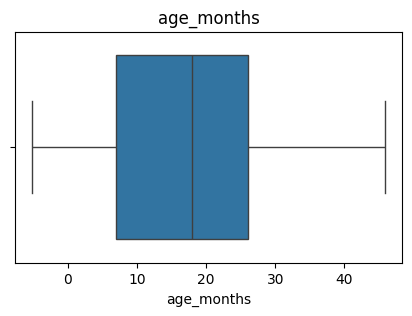

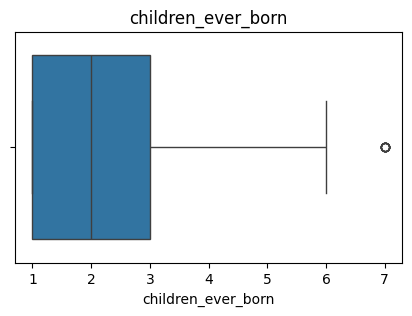

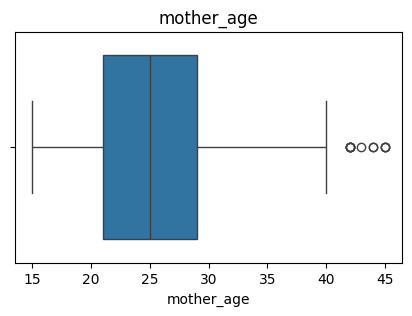

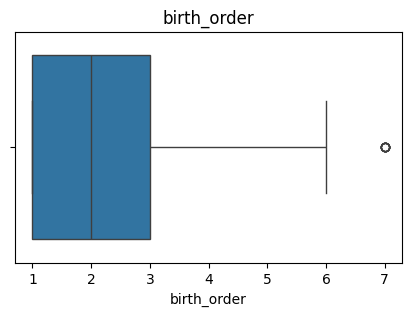

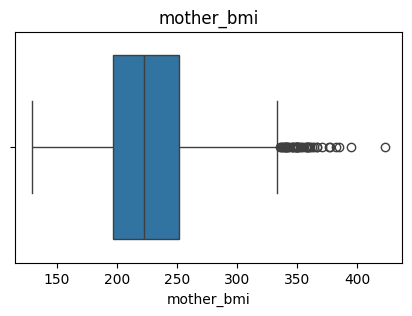

In [ ]:
for col in columns_to_check:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


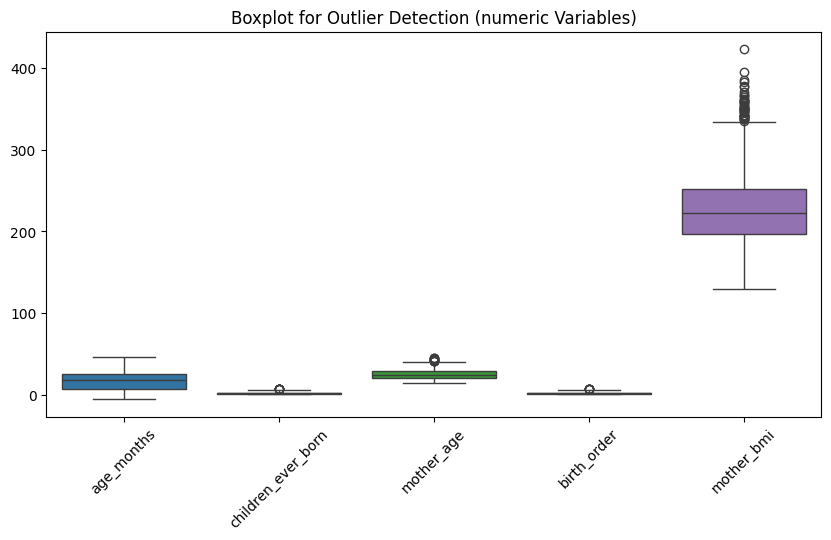

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[columns_to_check])
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection (numeric Variables)")
plt.show()



# whisker use to handle outlier

In [ ]:
import pandas as pd
import numpy as np

# 1. Define a helper to calculate bounds (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
def get_winsorize_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

cols = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi']

for col in cols:
    # Calculate bounds
    lw, uw = get_winsorize_bounds(df[col])

    # Clip values between lw and uw
    df[col] = df[col].clip(lower=lw, upper=uw)

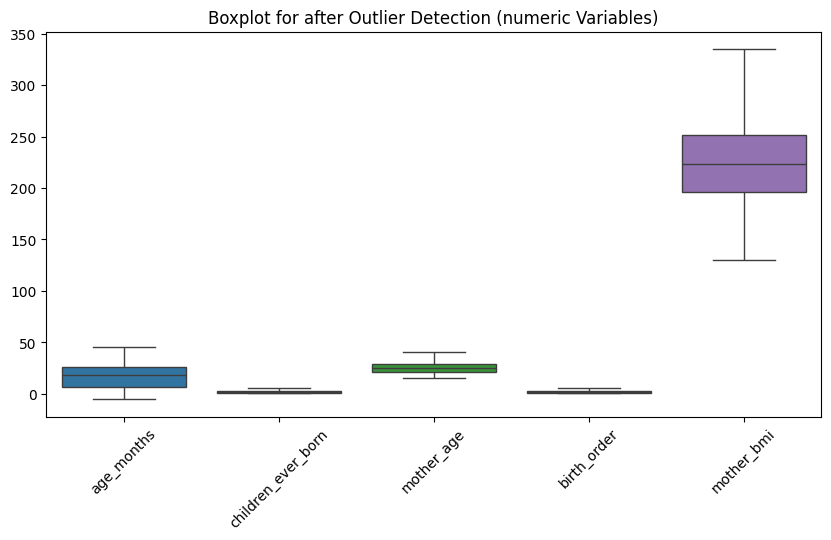

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[columns_to_check])
plt.xticks(rotation=45)
plt.title("Boxplot for after Outlier Detection (numeric Variables)")
plt.show()

### Scaling numerical variables

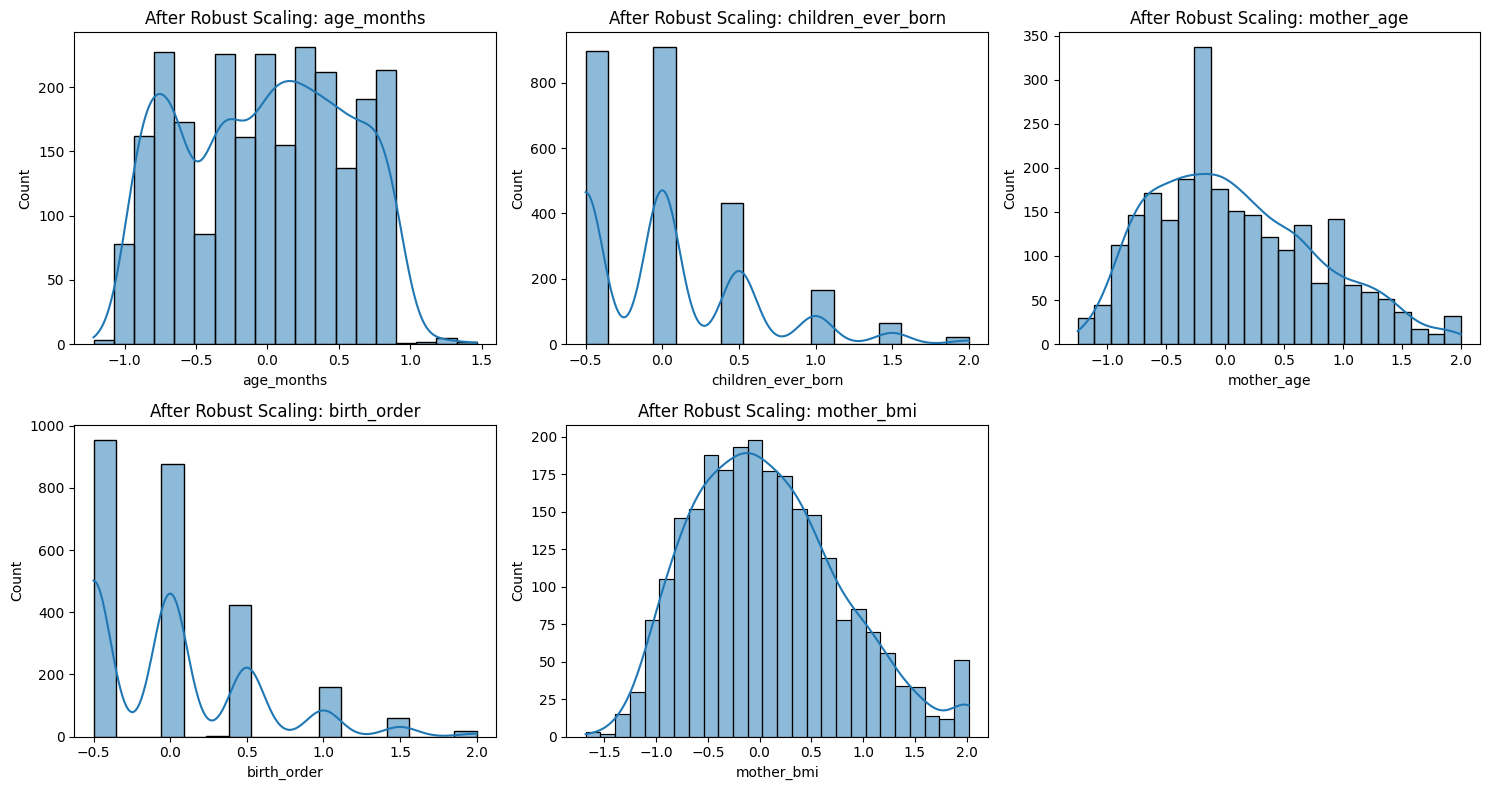

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Columns to scale
cols_to_scale = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi'
]

# Apply Robust Scaling
scaler = RobustScaler()
scaled_values = scaler.fit_transform(df[cols_to_scale])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=cols_to_scale,
    index=df.index
)

# Plot distributions after scaling
plt.figure(figsize=(15, 8))
for i, col in enumerate(cols_to_scale):
    plt.subplot(2, 3, i + 1)
    sns.histplot(scaled_df[col], kde=True)
    plt.title(f"After Robust Scaling: {col}")

plt.tight_layout()
plt.show()


# class imbalance checking

In [ ]:
# Class counts
stunted_counts = df['stunted'].value_counts()

# Class percentages
stunted_percent = df['stunted'].value_counts(normalize=True) * 100

print("Class Counts:")
print(stunted_counts)

print("\nClass Percentages (%):")
print(stunted_percent.round(2))


Class Counts:
stunted
0    1908
1     583
Name: count, dtype: int64

Class Percentages (%):
stunted
0    76.6
1    23.4
Name: proportion, dtype: float64


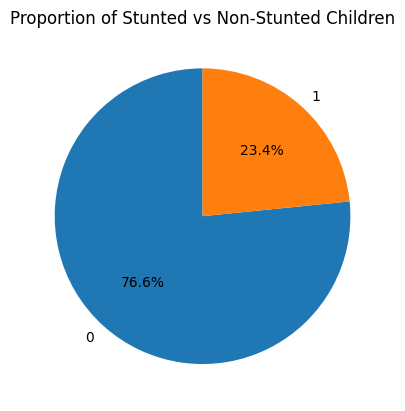

In [ ]:
df['stunted'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.ylabel('')
plt.title('Proportion of Stunted vs Non-Stunted Children')
plt.show()



# Train Test Split (80% train, 20% test)

In [ ]:
from sklearn.model_selection import train_test_split

# Target
y = df["stunted"].astype(int)

# Drop non-predictor columns
drop_cols = ["stunted", "haz", "sample_weight", "wt", "child_line"]

X = df.drop(columns=drop_cols, errors="ignore")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Sanity checks
print("Final feature count:", X.shape[1])
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Verify removal
print("haz in X?", "haz" in X.columns)
print("weight in X?", any(col in X.columns for col in ["sample_weight", "wt"]))
print("child_line in X?", "child_line" in X.columns)

Final feature count: 19
Train shape: (1992, 19)
Test shape: (499, 19)
haz in X? False
weight in X? False
child_line in X? False


# feature  engineering

In [ ]:
for i, feat in enumerate(X.columns, start=1):
    print(f"{i}. {feat}")

1. age_months
2. mother_edu
3. birth_order
4. mother_occ
5. children_ever_born
6. father_edu
7. division
8. mother_age
9. mother_bmi
10. father_occ_clean
11. skilled_birth
12. toilet_improved
13. delivery_place_3cat
14. has_tv_clean
15. has_electricity_clean
16. reads_newspaper_clean
17. small_at_birth
18. wants_more_children
19. wealth_index_clean


# 1. Filter Method: SelectKBest with Mutual Information

This selects top features based on mutual information (measures dependency between features and target).
It's fast and doesn't overfit, but ignores feature interactions.

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Work on a copy of existing X
X_fe = X.copy()
y_fe = y.copy()

# Handle missing values
X_fe = X_fe.fillna(X_fe.median(numeric_only=True))  # Numeric columns

for col in X_fe.select_dtypes(include=['object', 'category']).columns:
    X_fe[col] = X_fe[col].fillna(X_fe[col].mode()[0])  # Categorical columns

# Encode categorical variables
X_fe = pd.get_dummies(X_fe, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y_fe, test_size=0.2, stratify=y_fe, random_state=42
)

# Ensure y is numeric
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Initialize and fit selector
selector = SelectKBest(score_func=mutual_info_classif, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected features
selected_features = X_train.columns[selector.get_support()]
print("Selected features:")
for i, feat in enumerate(selected_features, start=1):
    print(f"{i}. {feat}")

Selected features:
1. age_months
2. children_ever_born
3. mother_bmi
4. mother_edu_1
5. mother_edu_3
6. father_occ_clean_3
7. father_occ_clean_7
8. delivery_place_3cat_2
9. has_electricity_clean_1
10. wealth_index_clean_5


In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split
import pandas as pd

# Use existing X and y
X_fs = X.copy()
y_fs = y.copy()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_fs, y_fs, test_size=0.2, stratify=y_fs, random_state=42
)

# Initialize filter selector
selector = SelectKBest(score_func=mutual_info_classif, k=15)

# Fit and transform
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]
print("Selected features:")
for i, feat in enumerate(selected_features, start=1):
    print(f"{i}. {feat}")

# Now use X_train_selected and X_test_selected for modeling

Selected features:
1. age_months
2. mother_edu
3. birth_order
4. mother_occ
5. children_ever_born
6. father_edu
7. mother_bmi
8. skilled_birth
9. toilet_improved
10. delivery_place_3cat
11. has_electricity_clean
12. reads_newspaper_clean
13. small_at_birth
14. wants_more_children
15. wealth_index_clean


# 2. Wrapper Method: Recursive Feature Elimination (RFE) with LogisticRegression
This recursively removes least important features using a model (here, LogisticRegression for multiclass). More accurate but slower.

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# Use existing X and y
X_rfe = X.copy()
y_rfe = y.copy()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_rfe, y_rfe, test_size=0.2, stratify=y_rfe, random_state=42
)

# Initialize wrapper selector
estimator = LogisticRegression(random_state=42, max_iter=1000)
selector = RFE(estimator, n_features_to_select=15)

# Fit and transform
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.support_]
print("Selected features:")
for i, feat in enumerate(selected_features, start=1):
    print(f"{i}. {feat}")



Selected features:
1. age_months
2. mother_edu
3. birth_order
4. mother_occ
5. children_ever_born
6. father_occ_clean
7. skilled_birth
8. toilet_improved
9. delivery_place_3cat
10. has_tv_clean
11. has_electricity_clean
12. reads_newspaper_clean
13. small_at_birth
14. wants_more_children
15. wealth_index_clean


# 3.Stepwise Backward Feature Selection Code

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd

# Use existing X and y
X_rfe = X.copy()
y_rfe = y.copy()

# Split data (stratified for imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X_rfe, y_rfe, test_size=0.2, stratify=y_rfe, random_state=42
)

# Initialize backward selector (RFE with LogisticRegression; select top 15 features)
estimator = LogisticRegression(random_state=42, max_iter=1000)  # Or CatBoostClassifier
selector = RFE(estimator, n_features_to_select=15, step=1)  # step=1 removes 1 feature per iteration

# Fit on training data
selector.fit(X_train, y_train)

# Get selected features
selected_features = X_train.columns[selector.support_]
print("Selected features:")
for i, feat in enumerate(selected_features, start=1):
    print(f"{i}. {feat}")

# Transform data to selected features
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Now use X_train_selected and X_test_selected for modeling

Selected features:
1. age_months
2. mother_edu
3. birth_order
4. mother_occ
5. children_ever_born
6. father_occ_clean
7. skilled_birth
8. toilet_improved
9. delivery_place_3cat
10. has_tv_clean
11. has_electricity_clean
12. reads_newspaper_clean
13. small_at_birth
14. wants_more_children
15. wealth_index_clean


# 4.Boruta Algorithm

In [ ]:
!pip install boruta


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.8 MB/s eta 0:00:00


In [ ]:
from boruta import BorutaPy


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

# Use existing split data directly
x_train_boruta = X_train.copy()
x_test_boruta  = X_test.copy()

# Convert to numpy arrays (Boruta requirement)
x_train_np = x_train_boruta.values
y_train_np = y_train.values


In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=45,
    n_jobs=-1,
    class_weight='balanced'
)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

# Use existing saved X and y
X_boruta = X.copy()
y_boruta = y.copy()

# Check X_boruta for issues before splitting
print("Data types in X_boruta:")
print(X_boruta.dtypes)
print("Any NaNs in X_boruta?", X_boruta.isnull().sum().sum() > 0)
print("Any non-numerical in X_boruta?", X_boruta.select_dtypes(include=[object]).shape[1] > 0)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_boruta, y_boruta, test_size=0.2, stratify=y_boruta, random_state=42
)

# Convert to numpy
try:
    X_train_np = np.array(X_train.values if hasattr(X_train, 'values') else X_train)
    y_train_np = np.array(y_train.values if hasattr(y_train, 'values') else y_train)
except Exception as e:
    print(f"Conversion error: {e}")
    raise

# Validate shapes and types
print("X_train_np shape:", X_train_np.shape, "Type:", type(X_train_np))
print("y_train_np shape:", y_train_np.shape, "Type:", type(y_train_np))

if X_train_np.ndim != 2:
    raise ValueError("X_train_np must be 2D. Reshape if needed.")
if y_train_np.ndim != 1:
    raise ValueError("y_train_np must be 1D.")

# Initialize RF
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Boruta
boruta = BorutaPy(estimator=rf, n_estimators='auto', verbose=2, random_state=45)

# Fit
try:
    boruta.fit(X_train_np, y_train_np)
    selected_features = X_train.columns[boruta.support_].tolist()
    print("Selected features:", selected_features)
except ValueError as e:
    print(f"Boruta fit error: {e}")
    print("Likely cause: Check X_boruta preprocessing or shapes above.")

Data types in X_boruta:
age_months                float64
mother_edu               category
birth_order               float64
mother_occ               category
children_ever_born        float64
father_edu               category
division                 category
mother_age                float64
mother_bmi                float64
father_occ_clean         category
skilled_birth            category
toilet_improved          category
delivery_place_3cat      category
has_tv_clean             category
has_electricity_clean    category
reads_newspaper_clean    category
small_at_birth           category
wants_more_children      category
wealth_index_clean       category
dtype: object
Any NaNs in X_boruta? False
Any non-numerical in X_boruta? False
X_train_np shape: (1992, 19) Type: <class 'numpy.ndarray'>
y_train_np shape: (1992,) Type: <class 'numpy.ndarray'>
Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	19
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	19
Rejected: 	0
Iteration: 	

# 5.Grey Wolf Optimizer (GWO)  Feature Selection

Works well for complex datasets,
 Handles non-linear relationships,
 Avoids local minima,
 Good balance between exploration & exploitation,

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

# Use existing X and y
X_gwo = X.copy()
y_gwo = y.copy()

n_features = X_gwo.shape[1]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_gwo, y_gwo, test_size=0.2, stratify=y_gwo, random_state=42
)

# Convert to numpy (FIX for slicing issue)
X_train_np = X_train.values
X_test_np = X_test.values

# GWO Parameters
n_wolves = 10
max_iter = 20
a_max = 2
a_min = 0

# Fitness function
def fitness_function(subset, X_train, X_test, y_train, y_test):
    if np.sum(subset) == 0:
        return 0
    try:
        selected_train = X_train[:, subset == 1]
        selected_test = X_test[:, subset == 1]

        model = CatBoostClassifier(iterations=50, verbose=0, random_state=42)
        model.fit(selected_train, y_train)

        y_pred = model.predict(selected_test)
        return accuracy_score(y_test, y_pred)

    except Exception as e:
        print(f"Fitness error: {e}")
        return 0

# Initialize population
population = np.random.randint(0, 2, (n_wolves, n_features))

# Initialize best wolves
alpha_pos = np.copy(population[0])
beta_pos = np.copy(population[1])
delta_pos = np.copy(population[2])
alpha_score = 0
beta_score = 0
delta_score = 0

# GWO Loop
for iter in range(max_iter):
    a = a_max - (a_max - a_min) * (iter / max_iter)

    for i in range(n_wolves):
        fitness = fitness_function(population[i], X_train_np, X_test_np, y_train, y_test)

        if fitness > alpha_score:
            alpha_score = fitness
            alpha_pos = np.copy(population[i])
        elif fitness > beta_score:
            beta_score = fitness
            beta_pos = np.copy(population[i])
        elif fitness > delta_score:
            delta_score = fitness
            delta_pos = np.copy(population[i])

    for i in range(n_wolves):
        for j in range(n_features):
            r1, r2 = np.random.rand(), np.random.rand()
            A1 = 2 * a * r1 - a
            C1 = 2 * r2
            D_alpha = abs(C1 * alpha_pos[j] - population[i][j])
            X1 = alpha_pos[j] - A1 * D_alpha

            r1, r2 = np.random.rand(), np.random.rand()
            A2 = 2 * a * r1 - a
            C2 = 2 * r2
            D_beta = abs(C2 * beta_pos[j] - population[i][j])
            X2 = beta_pos[j] - A2 * D_beta

            r1, r2 = np.random.rand(), np.random.rand()
            A3 = 2 * a * r1 - a
            C3 = 2 * r2
            D_delta = abs(C3 * delta_pos[j] - population[i][j])
            X3 = delta_pos[j] - A3 * D_delta

            new_pos = (X1 + X2 + X3) / 3
            population[i][j] = 1 if 1 / (1 + np.exp(-10 * (new_pos - 0.5))) > 0.5 else 0

    print(f"Iter {iter+1}: Best Score = {alpha_score:.4f}")

# Results (FIX: use X_gwo, not df)
selected_indices = np.where(alpha_pos == 1)[0]
selected_features = X_gwo.columns[selected_indices].tolist()

print("Selected features:", selected_features)
print("Best accuracy:", alpha_score)

Iter 1: Best Score = 0.7756
Iter 2: Best Score = 0.7776
Iter 3: Best Score = 0.7896
Iter 4: Best Score = 0.7896
Iter 5: Best Score = 0.7896
Iter 6: Best Score = 0.7896
Iter 7: Best Score = 0.7896
Iter 8: Best Score = 0.7896
Iter 9: Best Score = 0.7896
Iter 10: Best Score = 0.7896
Iter 11: Best Score = 0.7896
Iter 12: Best Score = 0.7896
Iter 13: Best Score = 0.7896
Iter 14: Best Score = 0.7896
Iter 15: Best Score = 0.7896
Iter 16: Best Score = 0.7896
Iter 17: Best Score = 0.7896
Iter 18: Best Score = 0.7896
Iter 19: Best Score = 0.7896
Iter 20: Best Score = 0.7896
Selected features: ['age_months', 'mother_occ', 'children_ever_born', 'division', 'toilet_improved', 'delivery_place_3cat', 'has_tv_clean', 'reads_newspaper_clean', 'wealth_index_clean']
Best accuracy: 0.7895791583166333


# snake optimization

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression  # Or CatBoostClassifier if installed

# Use existing saved X and y
X_so = X.copy()
y_so = y.copy()
n_features = X_so.shape[1]

# Split for fitness
X_train, X_test, y_train, y_test = train_test_split(
    X_so, y_so, test_size=0.2, stratify=y_so, random_state=42
)

# Convert to numpy for subset slicing
X_train_np = X_train.values
X_test_np = X_test.values

# SO Parameters
n_snakes = 20  # Population size
max_iter = 50  # Iterations
c1 = 1  # Control parameter
c2 = 0.5  # Another parameter

# Fitness function
def fitness_function(subset, X_train, X_test, y_train, y_test):
    if np.sum(subset) == 0:
        return 0
    try:
        selected_train = X_train[:, subset == 1]
        selected_test = X_test[:, subset == 1]
        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(selected_train, y_train)
        y_pred = model.predict(selected_test)
        return accuracy_score(y_test, y_pred)
    except Exception as e:
        print(f"Fitness error: {e}")
        return 0

# Initialize population (binary)
population = np.random.randint(0, 2, (n_snakes, n_features))

# Initialize best snake
best_snake = np.copy(population[0])
best_fitness = 0

# SO Main Loop
for iter in range(max_iter):
    fitness_values = np.array([
        fitness_function(population[i], X_train_np, X_test_np, y_train, y_test)
        for i in range(n_snakes)
    ])

    # Update best
    max_idx = np.argmax(fitness_values)
    if fitness_values[max_idx] > best_fitness:
        best_fitness = fitness_values[max_idx]
        best_snake = np.copy(population[max_idx])

    # Update population
    for i in range(n_snakes):
        for j in range(n_features):
            r1 = np.random.rand()
            r2 = np.random.rand()
            if r1 < c1:
                # Follow best snake
                population[i][j] = best_snake[j]
            elif r2 < c2:
                # Random walk
                population[i][j] = np.random.randint(0, 2)
            # Else, stay the same

    print(f"Iter {iter+1}: Best Fitness = {best_fitness:.4f}")

# Results
selected_indices = np.where(best_snake == 1)[0]
selected_features = X_so.columns[selected_indices].tolist()
print("Selected features:", selected_features)
print("Best accuracy:", best_fitness)

Iter 1: Best Fitness = 0.7735
Iter 2: Best Fitness = 0.7735
Iter 3: Best Fitness = 0.7735
Iter 4: Best Fitness = 0.7735
Iter 5: Best Fitness = 0.7735
Iter 6: Best Fitness = 0.7735
Iter 7: Best Fitness = 0.7735
Iter 8: Best Fitness = 0.7735
Iter 9: Best Fitness = 0.7735
Iter 10: Best Fitness = 0.7735
Iter 11: Best Fitness = 0.7735
Iter 12: Best Fitness = 0.7735
Iter 13: Best Fitness = 0.7735
Iter 14: Best Fitness = 0.7735
Iter 15: Best Fitness = 0.7735
Iter 16: Best Fitness = 0.7735
Iter 17: Best Fitness = 0.7735
Iter 18: Best Fitness = 0.7735
Iter 19: Best Fitness = 0.7735
Iter 20: Best Fitness = 0.7735
Iter 21: Best Fitness = 0.7735
Iter 22: Best Fitness = 0.7735
Iter 23: Best Fitness = 0.7735
Iter 24: Best Fitness = 0.7735
Iter 25: Best Fitness = 0.7735
Iter 26: Best Fitness = 0.7735
Iter 27: Best Fitness = 0.7735
Iter 28: Best Fitness = 0.7735
Iter 29: Best Fitness = 0.7735
Iter 30: Best Fitness = 0.7735
Iter 31: Best Fitness = 0.7735
Iter 32: Best Fitness = 0.7735
Iter 33: Best Fit

In [ ]:
import pandas as pd
import numpy as np

# Use existing saved X and y
X_fixed = X.copy()
y_fixed = y.copy()

feature_names = X_fixed.columns

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

# -----------------------------
# Split dataset
# -----------------------------
X_all = X.copy()
y_all = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

feature_names = X_train.columns

# -----------------------------
# 1 Mutual Information
# -----------------------------
mi = SelectKBest(mutual_info_classif, k='all')
mi.fit(X_train, y_train)

mi_rank = pd.Series(mi.scores_, index=feature_names).rank(ascending=False)

# -----------------------------
# 2 Random Forest Importance
# -----------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_rank = pd.Series(rf.feature_importances_, index=feature_names).rank(ascending=False)

# -----------------------------
# 3 RFE
# -----------------------------
lr = LogisticRegression(max_iter=1000)

rfe = RFE(lr, n_features_to_select=15)
rfe.fit(X_train, y_train)

rfe_rank = pd.Series(rfe.ranking_, index=feature_names)

# -----------------------------
# 4 LASSO
# -----------------------------
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

lasso_rank = pd.Series(np.abs(lasso.coef_), index=feature_names).rank(ascending=False)

# -----------------------------
# 5 Boruta
# -----------------------------
rf_boruta = RandomForestClassifier(n_estimators=200, random_state=42)

boruta = BorutaPy(rf_boruta, n_estimators='auto', random_state=42)

boruta.fit(X_train.to_numpy(), y_train.to_numpy())

boruta_rank = pd.Series(np.where(boruta.support_, 1, 2), index=feature_names)

# -----------------------------
# 6 Snake Optimization Feature Selection
# -----------------------------
from sklearn.metrics import accuracy_score

X_np = X_train.to_numpy()
y_np = y_train.to_numpy()

n_features = X_np.shape[1]

# parameters
n_snakes = 20
max_iter = 30

# initialize population
population = np.random.randint(0, 2, (n_snakes, n_features))

best_snake = population[0]
best_score = 0


def fitness_function(mask):
    if np.sum(mask) == 0:
        return 0

    X_selected = X_np[:, mask == 1]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_selected, y_np)

    score = model.score(X_selected, y_np)
    return score


for i in range(max_iter):

    scores = []

    for snake in population:
        score = fitness_function(snake)
        scores.append(score)

    scores = np.array(scores)

    best_idx = np.argmax(scores)

    if scores[best_idx] > best_score:
        best_score = scores[best_idx]
        best_snake = population[best_idx]

    # update population
    for j in range(n_snakes):
        rand = np.random.rand(n_features)
        population[j] = np.where(rand < 0.5, best_snake, population[j])


# Convert to ranking
snake_rank = pd.Series(best_snake, index=X_train.columns).rank(ascending=False)

# -----------------------------
# Combine All Rankings
# -----------------------------
rank_df = pd.DataFrame({
    'MI_Rank': mi_rank,
    'RF_Rank': rf_rank,
    'RFE_Rank': rfe_rank,
    'LASSO_Rank': lasso_rank,
    'Boruta_Rank': boruta_rank,
    'Snake_Rank': snake_rank,
})

# -----------------------------
# Average Rank
# -----------------------------
rank_df['Average_Rank'] = rank_df.mean(axis=1)

rank_df = rank_df.sort_values('Average_Rank')

print(rank_df)

# -----------------------------
# Top Features
# -----------------------------
top_features = rank_df.head(15)

print("\nTop 15 Features:")
print(top_features)

                       MI_Rank  RF_Rank  RFE_Rank  LASSO_Rank  Boruta_Rank  \
mother_edu                 1.0      9.0         1         2.0            2   
age_months                 6.0      2.0         1         6.0            2   
mother_bmi                 9.0      1.0         3         7.0            1   
mother_age                 4.0      3.0         5         8.0            2   
wealth_index_clean         3.0      5.0         1         3.0            2   
children_ever_born        13.0     10.0         1         1.0            2   
small_at_birth             7.0     13.0         1         4.0            2   
toilet_improved            5.0     14.0         1        14.0            2   
division                  17.0      4.0         2        14.0            2   
birth_order               14.0      8.0         1        14.0            2   
father_occ_clean          11.0      6.0         1        14.0            2   
skilled_birth             10.0     17.0         1        14.0   

In [ ]:
top_features = rank_df.head(15)

In [ ]:
selected_features = top_features.index

In [ ]:
# CREATE NEW DATASET WITH SELECTED FEATURES
X_selected = X[selected_features]
print(f"\n📈 Original features: {X.shape[1]} → Selected features: {X_selected.shape[1]}")
print(f"Feature reduction: {100*(1 - X_selected.shape[1]/X.shape[1]):.1f}%")


📈 Original features: 19 → Selected features: 15
Feature reduction: 21.1%


In [ ]:
# Now use X_selected and selected_features in your models!
print(f"\n🎯 Ready to use: X_selected and selected_features")
print("X_selected.shape =", X_selected.shape)


🎯 Ready to use: X_selected and selected_features
X_selected.shape = (2491, 15)


In [ ]:
print("\nColumns in X_selected:")
for col in X_selected.columns:
    print(col)

In [ ]:
# 1️⃣ Import libraries
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2️⃣ Define individual models with fixed random_state
logreg = LogisticRegression(max_iter=1000, random_state=42)
svm = SVC(probability=True, random_state=42)  # probability=True needed for soft voting
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
nb = GaussianNB()

# 3️⃣ Create a voting ensemble (soft voting for probabilities)
ensemble_model = VotingClassifier(
    estimators=[
        ('LogReg', logreg),
        ('SVM', svm),
        ('AdaBoost', ada),
        ('RandomForest', rf),
        ('GB', gb),
        ('DT', dt),
        ('KNN', knn),
        ('NB', nb)
    ],
    voting='soft'  # soft voting averages predicted probabilities
)

# 4️⃣ Train ensemble on your selected features
ensemble_model.fit(X_train_selected, y_train)

# 5️⃣ Make predictions
y_pred = ensemble_model.predict(X_test_selected)

# 6️⃣ Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Ensemble Accuracy:", accuracy)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Ensemble Accuracy: 0.7655310621242485

Confusion Matrix:
 [[370  12]
 [105  12]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.97      0.86       382
           1       0.50      0.10      0.17       117

    accuracy                           0.77       499
   macro avg       0.64      0.54      0.52       499
weighted avg       0.71      0.77      0.70       499



# Now heading to model fit step.

In [ ]:
import xgboost as xgb
import lightgbm as lgb
# ... other imports ...

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(max_depth=10, n_estimators=100, n_jobs=-1, random_state=42),  # Reduced
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'XGBoost': xgb.XGBClassifier(     # ✅ FIXED
        n_estimators=100,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(   # ✅ FIXED
        n_estimators=100,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score
)
import numpy as np
import pandas as pd

# Scale for ALL models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========== 10 MODELS ==========
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(max_depth=10, n_estimators=100, n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1, verbose=-1)
}

# ========== TRAIN & EVALUATE ALL 10 ==========
results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"TRAINING: {name}")
    print(f"{'='*50}")

    try:
        # Use scaled data for ALL models
        X_fit, X_pred = X_train_scaled, X_test_scaled

        model.fit(X_fit, y_train)
        y_pred = model.predict(X_pred)

        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_pred)[:, 1]
        else:
            y_prob = model.decision_function(X_pred)

        train_acc = accuracy_score(y_train, model.predict(X_fit)) * 100
        test_acc = accuracy_score(y_test, y_pred) * 100

        print("Train Accuracy (%):", round(train_acc, 2))
        print("Test Accuracy (%):", round(test_acc, 2))

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        print("TN {}".format(cm[0, 0]))
        print("FP {}".format(cm[0, 1]))
        print("FN {}".format(cm[1, 0]))
        print("TP {}".format(cm[1, 1]))

        print("Accuracy rate {:.2f}".format((cm[0, 0] + cm[1, 1]) / np.sum(cm) * 100))
        print("Misclassification rate {:.2f}".format((cm[0, 1] + cm[1, 0]) / np.sum(cm) * 100))

        # Metrics
        print("Precision:", precision_score(y_test, y_pred))
        print("Recall:", recall_score(y_test, y_pred))
        print("F1-score:", f1_score(y_test, y_pred))
        print("ROC-AUC:", roc_auc_score(y_test, y_prob))

        # Store results
        results.append({
            'Model': name,
            'Train_Acc': train_acc,
            'Test_Acc': test_acc,
            'F1': f1_score(y_test, y_pred),
            'ROC_AUC': roc_auc_score(y_test, y_prob),
            'Overfit_Gap': (train_acc - test_acc) / 100
        })

        print("-" * 50)

    except Exception as e:
        print(f"❌ ERROR in {name}: {str(e)}")
        results.append({'Model': name, 'Error': str(e)})

# ========== SUMMARY TABLE ==========
results_df = pd.DataFrame(results).sort_values('Test_Acc', ascending=False)
print("\n🏆 FINAL RANKING (Test Accuracy):")
print("=" * 60)
print(results_df.round(3).to_string(index=False))


TRAINING: Logistic Regression
Train Accuracy (%): 77.71
Test Accuracy (%): 75.95
TN 371
FP 11
FN 109
TP 8
Accuracy rate 75.95
Misclassification rate 24.05
Precision: 0.42105263157894735
Recall: 0.06837606837606838
F1-score: 0.11764705882352941
ROC-AUC: 0.6731104846288093
--------------------------------------------------

TRAINING: K-Nearest Neighbors
Train Accuracy (%): 81.48
Test Accuracy (%): 75.15
TN 350
FP 32
FN 92
TP 25
Accuracy rate 75.15
Misclassification rate 24.85
Precision: 0.43859649122807015
Recall: 0.21367521367521367
F1-score: 0.28735632183908044
ROC-AUC: 0.6135051684789905
--------------------------------------------------

TRAINING: Decision Tree
Train Accuracy (%): 79.77
Test Accuracy (%): 75.55
TN 364
FP 18
FN 104
TP 13
Accuracy rate 75.55
Misclassification rate 24.45
Precision: 0.41935483870967744
Recall: 0.1111111111111111
F1-score: 0.17567567567567569
ROC-AUC: 0.6707276144448919
--------------------------------------------------

TRAINING: Random Forest
Train Acc

# KNN

In [ ]:
# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [ ]:
print("Train Accuracy (%):", knn.score(X_train, y_train) * 100)
print("Test Accuracy (%):", knn.score(X_test, y_test) * 100)

Train Accuracy (%): 79.21686746987952
Test Accuracy (%): 72.94589178356713


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Cross-validation on training set
cv_scores = cross_val_score(knn, X_train, y_train, cv=5)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

KNN Accuracy: 0.7295

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       382
           1       0.33      0.15      0.21       117

    accuracy                           0.73       499
   macro avg       0.56      0.53      0.52       499
weighted avg       0.67      0.73      0.69       499

CV Scores: [0.72681704 0.71679198 0.75628141 0.72864322 0.71105528]
Mean CV Accuracy: 0.7279 (+/- 0.0312)


In [ ]:
# ========== Import Libraries ==========
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ========== Scale ALL DATA ==========
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========== Define Models ==========
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

# ========== Train and Evaluate All Models ==========
results = []

print("=" * 80)
print("MODEL COMPARISON - ALL SCALED")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")

    # ✅ ALL models use scaled data
    model.fit(X_train_scaled, y_train)

    train_acc = model.score(X_train_scaled, y_train) * 100
    test_acc = model.score(X_test_scaled, y_test) * 100
    y_pred = model.predict(X_test_scaled)

    results.append({
        'Model': name,
        'Train Accuracy (%)': round(train_acc, 2),
        'Test Accuracy (%)': round(test_acc, 2),
        'Predictions': y_pred
    })

    print(f"  ✓ Train Accuracy: {train_acc:.2f}%")
    print(f"  ✓ Test Accuracy:  {test_acc:.2f}%")

# ========== Create Results DataFrame ==========
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(results_df[['Model', 'Train Accuracy (%)', 'Test Accuracy (%)']].to_string(index=False))

# ========== Best Model ==========
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Test Accuracy (%)']

print("\n" + "=" * 80)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.2f}%")
print("=" * 80)

# ========== Detailed Evaluation for Best Model ==========
best_predictions = results_df.iloc[0]['Predictions']

print("\n" + "=" * 80)
print(f"DETAILED EVALUATION - {best_model_name}")
print("=" * 80)

print("\n📊 CONFUSION MATRIX:")
print(confusion_matrix(y_test, best_predictions))

print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, best_predictions))

MODEL COMPARISON - ALL SCALED

Training Logistic Regression...
  ✓ Train Accuracy: 77.71%
  ✓ Test Accuracy:  75.95%

Training K-Nearest Neighbors...
  ✓ Train Accuracy: 81.48%
  ✓ Test Accuracy:  75.15%

Training Decision Tree...
  ✓ Train Accuracy: 100.00%
  ✓ Test Accuracy:  65.53%

Training Random Forest...
  ✓ Train Accuracy: 100.00%
  ✓ Test Accuracy:  76.35%

Training Gradient Boosting...
  ✓ Train Accuracy: 81.98%
  ✓ Test Accuracy:  75.95%

Training AdaBoost...
  ✓ Train Accuracy: 76.96%
  ✓ Test Accuracy:  76.95%

Training SVM...
  ✓ Train Accuracy: 78.87%
  ✓ Test Accuracy:  77.56%

Training Naive Bayes...
  ✓ Train Accuracy: 72.29%
  ✓ Test Accuracy:  70.94%

SUMMARY TABLE
              Model  Train Accuracy (%)  Test Accuracy (%)
                SVM               78.87              77.56
           AdaBoost               76.96              76.95
      Random Forest              100.00              76.35
Logistic Regression               77.71              75.95
  Gradient 

🎓 LEARNING CURVES FOR ALL MODELS
Computing learning curve for Random Forest...

Random Forest: Final Train-Val Gap = 82.14%
⚠️ WARNING: Possible Overfitting!
Random Forest        | Train F1: 1.000 | Val F1: 0.178 | Test F1: 0.169
Computing learning curve for Decision Tree...

Decision Tree: Final Train-Val Gap = 18.28%
⚠️ WARNING: Possible Overfitting!
Decision Tree        | Train F1: 0.471 | Val F1: 0.288 | Test F1: 0.115
Computing learning curve for AdaBoost...

AdaBoost: Final Train-Val Gap = 2.56%
✅ Good: No significant overfitting
AdaBoost             | Train F1: 0.173 | Val F1: 0.147 | Test F1: 0.094
Computing learning curve for Gradient Boosting...

Gradient Boosting: Final Train-Val Gap = 24.38%
⚠️ WARNING: Possible Overfitting!
Gradient Boosting    | Train F1: 0.442 | Val F1: 0.198 | Test F1: 0.178
Computing learning curve for Logistic Regression...

Logistic Regression: Final Train-Val Gap = 0.15%
✅ Good: No significant overfitting
Logistic Regression  | Train F1: 0.164 | Val

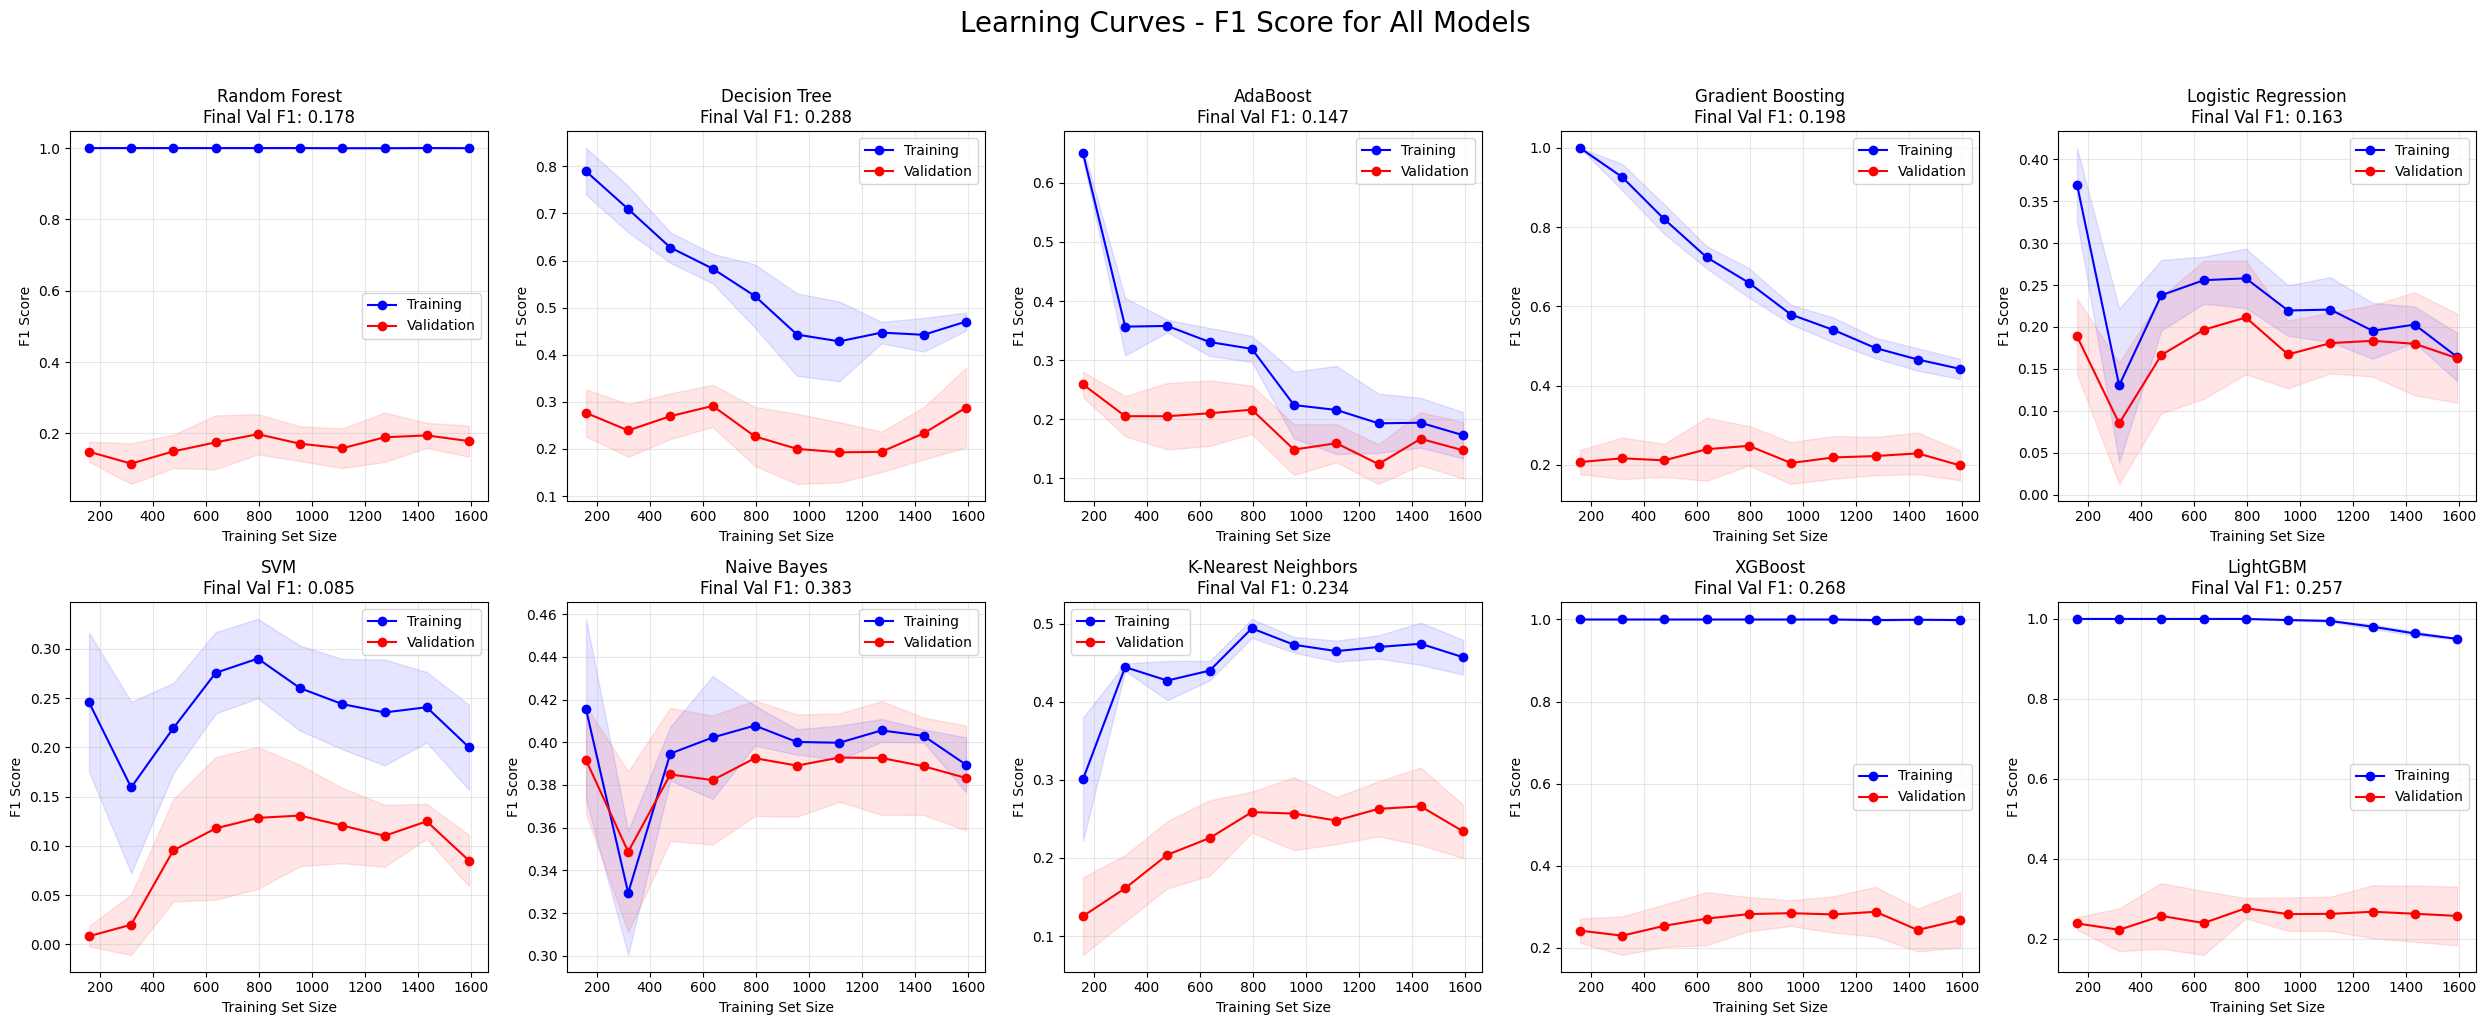


📊 FINAL PERFORMANCE SUMMARY
              Model  Test F1  Test ROC  Train F1
        Naive Bayes   0.3612    0.6344    0.3907
            XGBoost   0.3027    0.5891    0.9924
K-Nearest Neighbors   0.2874    0.6135    0.4597
           LightGBM   0.2249    0.6292    0.8988
  Gradient Boosting   0.1781    0.6544    0.3987
      Random Forest   0.1690    0.6459    1.0000
Logistic Regression   0.1176    0.6731    0.1685
      Decision Tree   0.1151    0.6355    0.3345
                SVM   0.1111    0.6520    0.2042
           AdaBoost   0.0945    0.6631    0.1388


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, roc_auc_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Your data (use selected_features)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Fix data types
def fix_data_types(X):
    X_fixed = X.copy()
    for col in X.columns:
        X_fixed[col] = pd.to_numeric(X_fixed[col], errors='coerce').fillna(0)
    return X_fixed

X_train_fixed = fix_data_types(X_train)
X_test_fixed = fix_data_types(X_test)

print("🎓 LEARNING CURVES FOR ALL MODELS")
print("="*60)

# Scale all models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fixed)
X_test_scaled = scaler.transform(X_test_fixed)

# Define all models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1)
}

# ==============================================
# LEARNING CURVES
# ==============================================
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.ravel()

train_sizes = np.linspace(0.1, 1.0, 10)
for idx, (name, model) in enumerate(models.items()):
    print(f"Computing learning curve for {name}...")

    # Use scaled data for all models
    X_train_model = X_train_scaled
    X_test_model = X_test_scaled

    # Learning curve
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_model, y_train,
        train_sizes=train_sizes,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    # Calculate means and std
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    # Plot
    axes[idx].plot(train_sizes, train_mean, 'o-', color='blue', label='Training')
    axes[idx].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    axes[idx].plot(train_sizes, val_mean, 'o-', color='red', label='Validation')
    axes[idx].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
    axes[idx].set_title(f'{name}\nFinal Val F1: {val_mean[-1]:.3f}')
    axes[idx].set_xlabel('Training Set Size')
    axes[idx].set_ylabel('F1 Score')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

    # Calculate actual percentage gap
    final_gap_pct = (train_mean[-1] - val_mean[-1]) * 100
    print(f"\n{name}: Final Train-Val Gap = {final_gap_pct:.2f}%")

    if final_gap_pct > 10:
        print("⚠️ WARNING: Possible Overfitting!")
    elif final_gap_pct > 5:
        print("⚡ WARNING: Mild Overfitting")
    else:
        print("✅ Good: No significant overfitting")

    # Print final performance
    model.fit(X_train_model, y_train)
    final_f1 = f1_score(y_test, model.predict(X_test_model))
    print(f"{name:20} | Train F1: {train_mean[-1]:.3f} | Val F1: {val_mean[-1]:.3f} | Test F1: {final_f1:.3f}")

plt.suptitle('Learning Curves - F1 Score for All Models', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# ==============================================
# SUMMARY TABLE
# ==============================================
results = []
for name, model in models.items():
    X_train_model = X_train_scaled
    X_test_model = X_test_scaled

    model.fit(X_train_model, y_train)
    y_pred = model.predict(X_test_model)

    results.append({
        'Model': name,
        'Test F1': f1_score(y_test, y_pred),
        'Test ROC': roc_auc_score(y_test, model.predict_proba(X_test_model)[:, 1]),
        'Train F1': f1_score(y_train, model.predict(X_train_model))
    })

results_df = pd.DataFrame(results).sort_values('Test F1', ascending=False)
print("\n📊 FINAL PERFORMANCE SUMMARY")
print("="*50)
print(results_df.round(4).to_string(index=False))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# ==============================
# MODEL DICTIONARY (WITH XGBOOST)
# ==============================
models_dict = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1)
}

# ==============================
# OVERFITTING CHECK FUNCTION
# ==============================
def quick_overfit_check_classification(models_dict, X_train, X_test, y_train, y_test):
    results = []

    # Proper scaling: fit only on training data, then transform both
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for name, model in models_dict.items():
        print(f"Training {name}...")

        # Fit model on scaled training data
        model.fit(X_train_scaled, y_train)

        # Predictions
        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

        # Accuracy
        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)
        gap = train_acc - test_acc

        # ROC-AUC (binary safe)
        auc_info = ""
        if hasattr(model, "predict_proba"):
            try:
                train_proba = model.predict_proba(X_train_scaled)[:, 1]
                test_proba = model.predict_proba(X_test_scaled)[:, 1]

                train_auc = roc_auc_score(y_train, train_proba)
                test_auc = roc_auc_score(y_test, test_proba)
                auc_gap = train_auc - test_auc

                auc_info = f" | AUC Gap: {auc_gap:.3f}"
            except:
                pass

        # Overfitting status
        if gap > 0.08:
            status = "🔴 OVERFITTING!"
        elif gap > 0.03:
            status = "🟡 Moderate"
        else:
            status = "🟢 Good"

        # Store results
        results.append({
            'Model': name,
            'Train Acc': round(train_acc, 3),
            'Test Acc': round(test_acc, 3),
            'Gap': round(gap, 3),
            'Status': status
        })

        print(f"{name:20} | Train: {train_acc:.3f} | Test: {test_acc:.3f} | Gap: {gap:.3f} {status}{auc_info}")

    # Summary table
    df_results = pd.DataFrame(results).sort_values('Test Acc', ascending=False)

    print("\n" + "="*70)
    print("📊 FINAL OVERFITTING SUMMARY")
    print("="*70)
    print(df_results.to_string(index=False))

    overfit_count = sum(df_results['Gap'] > 0.08)
    print(f"\n📊 SUMMARY: {overfit_count}/{len(models_dict)} models are OVERFITTING!")

    return df_results

# ==============================
# RUN CHECK ON YOUR DATA
# ==============================
results_df = quick_overfit_check_classification(
    models_dict, X_train, X_test, y_train, y_test
)

Training Random Forest...
Random Forest        | Train: 1.000 | Test: 0.764 | Gap: 0.236 🔴 OVERFITTING! | AUC Gap: 0.354
Training Decision Tree...
Decision Tree        | Train: 0.806 | Test: 0.754 | Gap: 0.053 🟡 Moderate | AUC Gap: 0.148
Training AdaBoost...
AdaBoost             | Train: 0.770 | Test: 0.770 | Gap: 0.000 🟢 Good | AUC Gap: 0.046
Training Gradient Boosting...
Gradient Boosting    | Train: 0.820 | Test: 0.760 | Gap: 0.060 🟡 Moderate | AUC Gap: 0.198
Training Logistic Regression...
Logistic Regression  | Train: 0.777 | Test: 0.760 | Gap: 0.018 🟢 Good | AUC Gap: 0.005
Training SVM...
SVM                  | Train: 0.789 | Test: 0.776 | Gap: 0.013 🟢 Good | AUC Gap: 0.213
Training Naive Bayes...
Naive Bayes          | Train: 0.723 | Test: 0.709 | Gap: 0.013 🟢 Good | AUC Gap: 0.029
Training K-Nearest Neighbors...
K-Nearest Neighbors  | Train: 0.815 | Test: 0.752 | Gap: 0.063 🟡 Moderate | AUC Gap: 0.207
Training XGBoost...
XGBoost              | Train: 0.996 | Test: 0.741 | Gap: 

In [ ]:
# Extract SVM results
svm_row = results_df[results_df['Model'] == 'SVM'].iloc[0]

svm_test_acc = svm_row['Test Acc'] * 100
svm_gap = svm_row['Gap'] * 100
svm_status = svm_row['Status']

print("\n📌 MODEL INTERPRETATION")
print("="*50)

print(f"SVM achieved the highest test accuracy of {svm_test_acc:.1f}%,")
print(f"with a very low generalization gap of {svm_gap:.1f}% ({svm_status}).")

print("\nThis indicates that SVM not only performs best on unseen data,")
print("but also maintains strong generalization ability without overfitting.")

print("\n👉 Therefore, SVM is considered the best model for this dataset.")


📌 MODEL INTERPRETATION
SVM achieved the highest test accuracy of 77.6%,
with a very low generalization gap of 1.3% (🟢 Good).

This indicates that SVM not only performs best on unseen data,
but also maintains strong generalization ability without overfitting.

👉 Therefore, SVM is considered the best model for this dataset.


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Scale once
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

for name, model in models_dict.items():
    print(f"Evaluating {name}...")

    # ✅ Use scaled data for ALL models
    X_fit, X_eval = X_train_scaled, X_test_scaled

    # Fit model
    model.fit(X_fit, y_train)

    # Predict class
    y_pred = model.predict(X_eval)

    # Predict probability / score for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_eval)
    else:
        y_prob = None

    results.append({
        'Model': name,
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1 Score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4) if y_prob is not None else None
    })

results_df = pd.DataFrame(results)
print("\n📊 SIMPLE EVALUATION TABLE")
print(results_df.to_string(index=False))

Evaluating Random Forest...
Evaluating Decision Tree...
Evaluating AdaBoost...
Evaluating Gradient Boosting...
Evaluating Logistic Regression...
Evaluating SVM...
Evaluating Naive Bayes...
Evaluating K-Nearest Neighbors...
Evaluating XGBoost...
Evaluating LightGBM...

📊 SIMPLE EVALUATION TABLE
              Model  Precision  Recall  F1 Score  ROC-AUC
      Random Forest     0.4800  0.1026    0.1690   0.6459
      Decision Tree     0.3636  0.0684    0.1151   0.6355
           AdaBoost     0.6000  0.0513    0.0945   0.6631
  Gradient Boosting     0.4483  0.1111    0.1781   0.6544
Logistic Regression     0.4211  0.0684    0.1176   0.6731
                SVM     0.7778  0.0598    0.1111   0.6520
        Naive Bayes     0.3727  0.3504    0.3612   0.6344
K-Nearest Neighbors     0.4386  0.2137    0.2874   0.6135
            XGBoost     0.4118  0.2393    0.3027   0.5891
           LightGBM     0.3654  0.1624    0.2249   0.6292


# SVM - 77.6%, 77.8%, 65.3% but 6%, 11.2%